<h1><center><font color=magenta face=georgia>Credit Card Customer Segmentation</font></center></h1>
<b>Dataset link : </b><a href="https://www.kaggle.com/code/des137/customer-segmentation-credit-cards/input?select=CC+GENERAL.csv">Kaggle dataset</a><br>
<p style="font-family: verdona;">
<b>Data Overview</b>
<pre><p style="font-family: verdona;">
<b>CUST_ID : </b>Identification of Credit Card holder (Categorical)
-------------------------------------------------------------------------------------------------------------------
<b>BALANCE : </b>Balance amount left in their account to make purchases
-------------------------------------------------------------------------------------------------------------------
<b>BALANCE_FREQUENCY : </b>How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 
0 = not frequently updated)
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASES : </b>Amount of purchases made from account
-------------------------------------------------------------------------------------------------------------------
<b>ONEOFF_PURCHASES : </b>Maximum purchase amount done in one-go
-------------------------------------------------------------------------------------------------------------------
<b>INSTALLMENTS_PURCHASES : </b>Amount of purchase done in installment
-------------------------------------------------------------------------------------------------------------------
<b>CASH_ADVANCE : </b>Cash in advance given by the user
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASES_FREQUENCY : </b>How frequently the Purchases are being made, score between 0 and 1 (1 = frequently 
purchased, 0 = not frequently purchased)
-------------------------------------------------------------------------------------------------------------------
<b>ONEOFFPURCHASESFREQUENCY : </b>How frequently Purchases are happening in one-go (1 = frequently purchased, 
0 = not frequently purchased)
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASESINSTALLMENTSFREQUENCY :</b> How frequently purchases in installments are being done (1 = frequently done,
0 = not frequently done)
-------------------------------------------------------------------------------------------------------------------
<b>CASHADVANCEFREQUENCY : </b>How frequently the cash in advance being paid
-------------------------------------------------------------------------------------------------------------------
<b>CASHADVANCETRX : </b>Number of Transactions made with "Cash in Advanced"
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASES_TRX : </b>Numbe of purchase transactions made
-------------------------------------------------------------------------------------------------------------------
<b>CREDIT_LIMIT : </b>Limit of Credit Card for user
-------------------------------------------------------------------------------------------------------------------
<b>PAYMENTS : </b>Amount of Payment done by user
-------------------------------------------------------------------------------------------------------------------
<b>MINIMUM_PAYMENTS : </b>Minimum amount of payments made by user
-------------------------------------------------------------------------------------------------------------------
<b>PRCFULLPAYMENT :</b> Percent of full payment paid by user
-------------------------------------------------------------------------------------------------------------------
<b>TENURE :</b> Tenure of credit card service for user

<center><font color=magenta face=georgia><h1>Importing Libraries

In [1]:
#============================================= preprocessing libraries =================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings


#============================================= visualization libraries ==================================================
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Image, display


#============================================= statistical libraries ====================================================
import numpy as np


#============================================ clustering models, evaluation libraries ====================================
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#============================================ Pipeline libraries =========================================================
import joblib
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

<center><font color=magenta face=georgia><h1>Importing Data

In [2]:
df = pd.read_csv('datasets/Customer Data.csv')
print(df.shape)
df.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

<center><h1><font face=georgia color=magenta>Data Cleaning and Preprocessing

In [4]:
len(df) == len(df.CUST_ID.unique())

True

<h4><font face=verdona><hr>Dropping ID column as all of the values are unique and doesn't bring any value to the data<hr>

In [5]:
df.drop(columns=['CUST_ID'], inplace=True)

<h4><font face=verdona><hr>Dropping duplicate records<hr>

In [6]:
df.duplicated().sum()

np.int64(0)

<h4><font face=verdona><hr>Handling Missing values<hr>

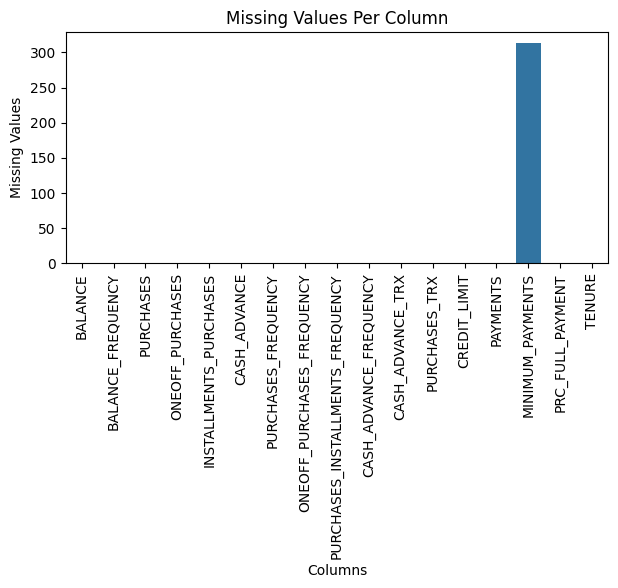

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,3))
missing_values = df.isnull().sum()  
sns.barplot(x=missing_values.index, y=missing_values.values)  
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.title("Missing Values Per Column")
plt.show()


<h4><font face=verdona><hr>We can drop the missing records as the number of missing records is minimal<hr>

In [8]:
df.dropna(inplace=True)

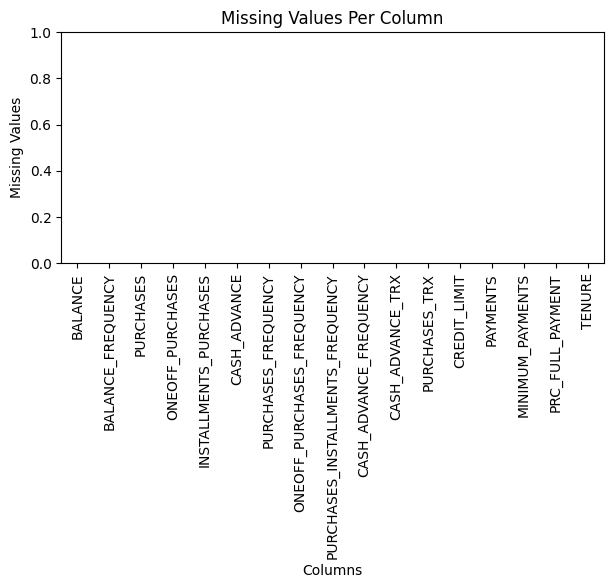

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,3))
missing_values = df.isnull().sum()  
sns.barplot(x=missing_values.index, y=missing_values.values)  
plt.xticks(rotation=90)
plt.ylim(0, missing_values.values.max() + 1)
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.title("Missing Values Per Column")
plt.show()

<h4><font face=verdona><hr>Data in entirely Numeric, thus encoding is not required<hr>

<center><h1><font face=georgia color=magenta>EDA

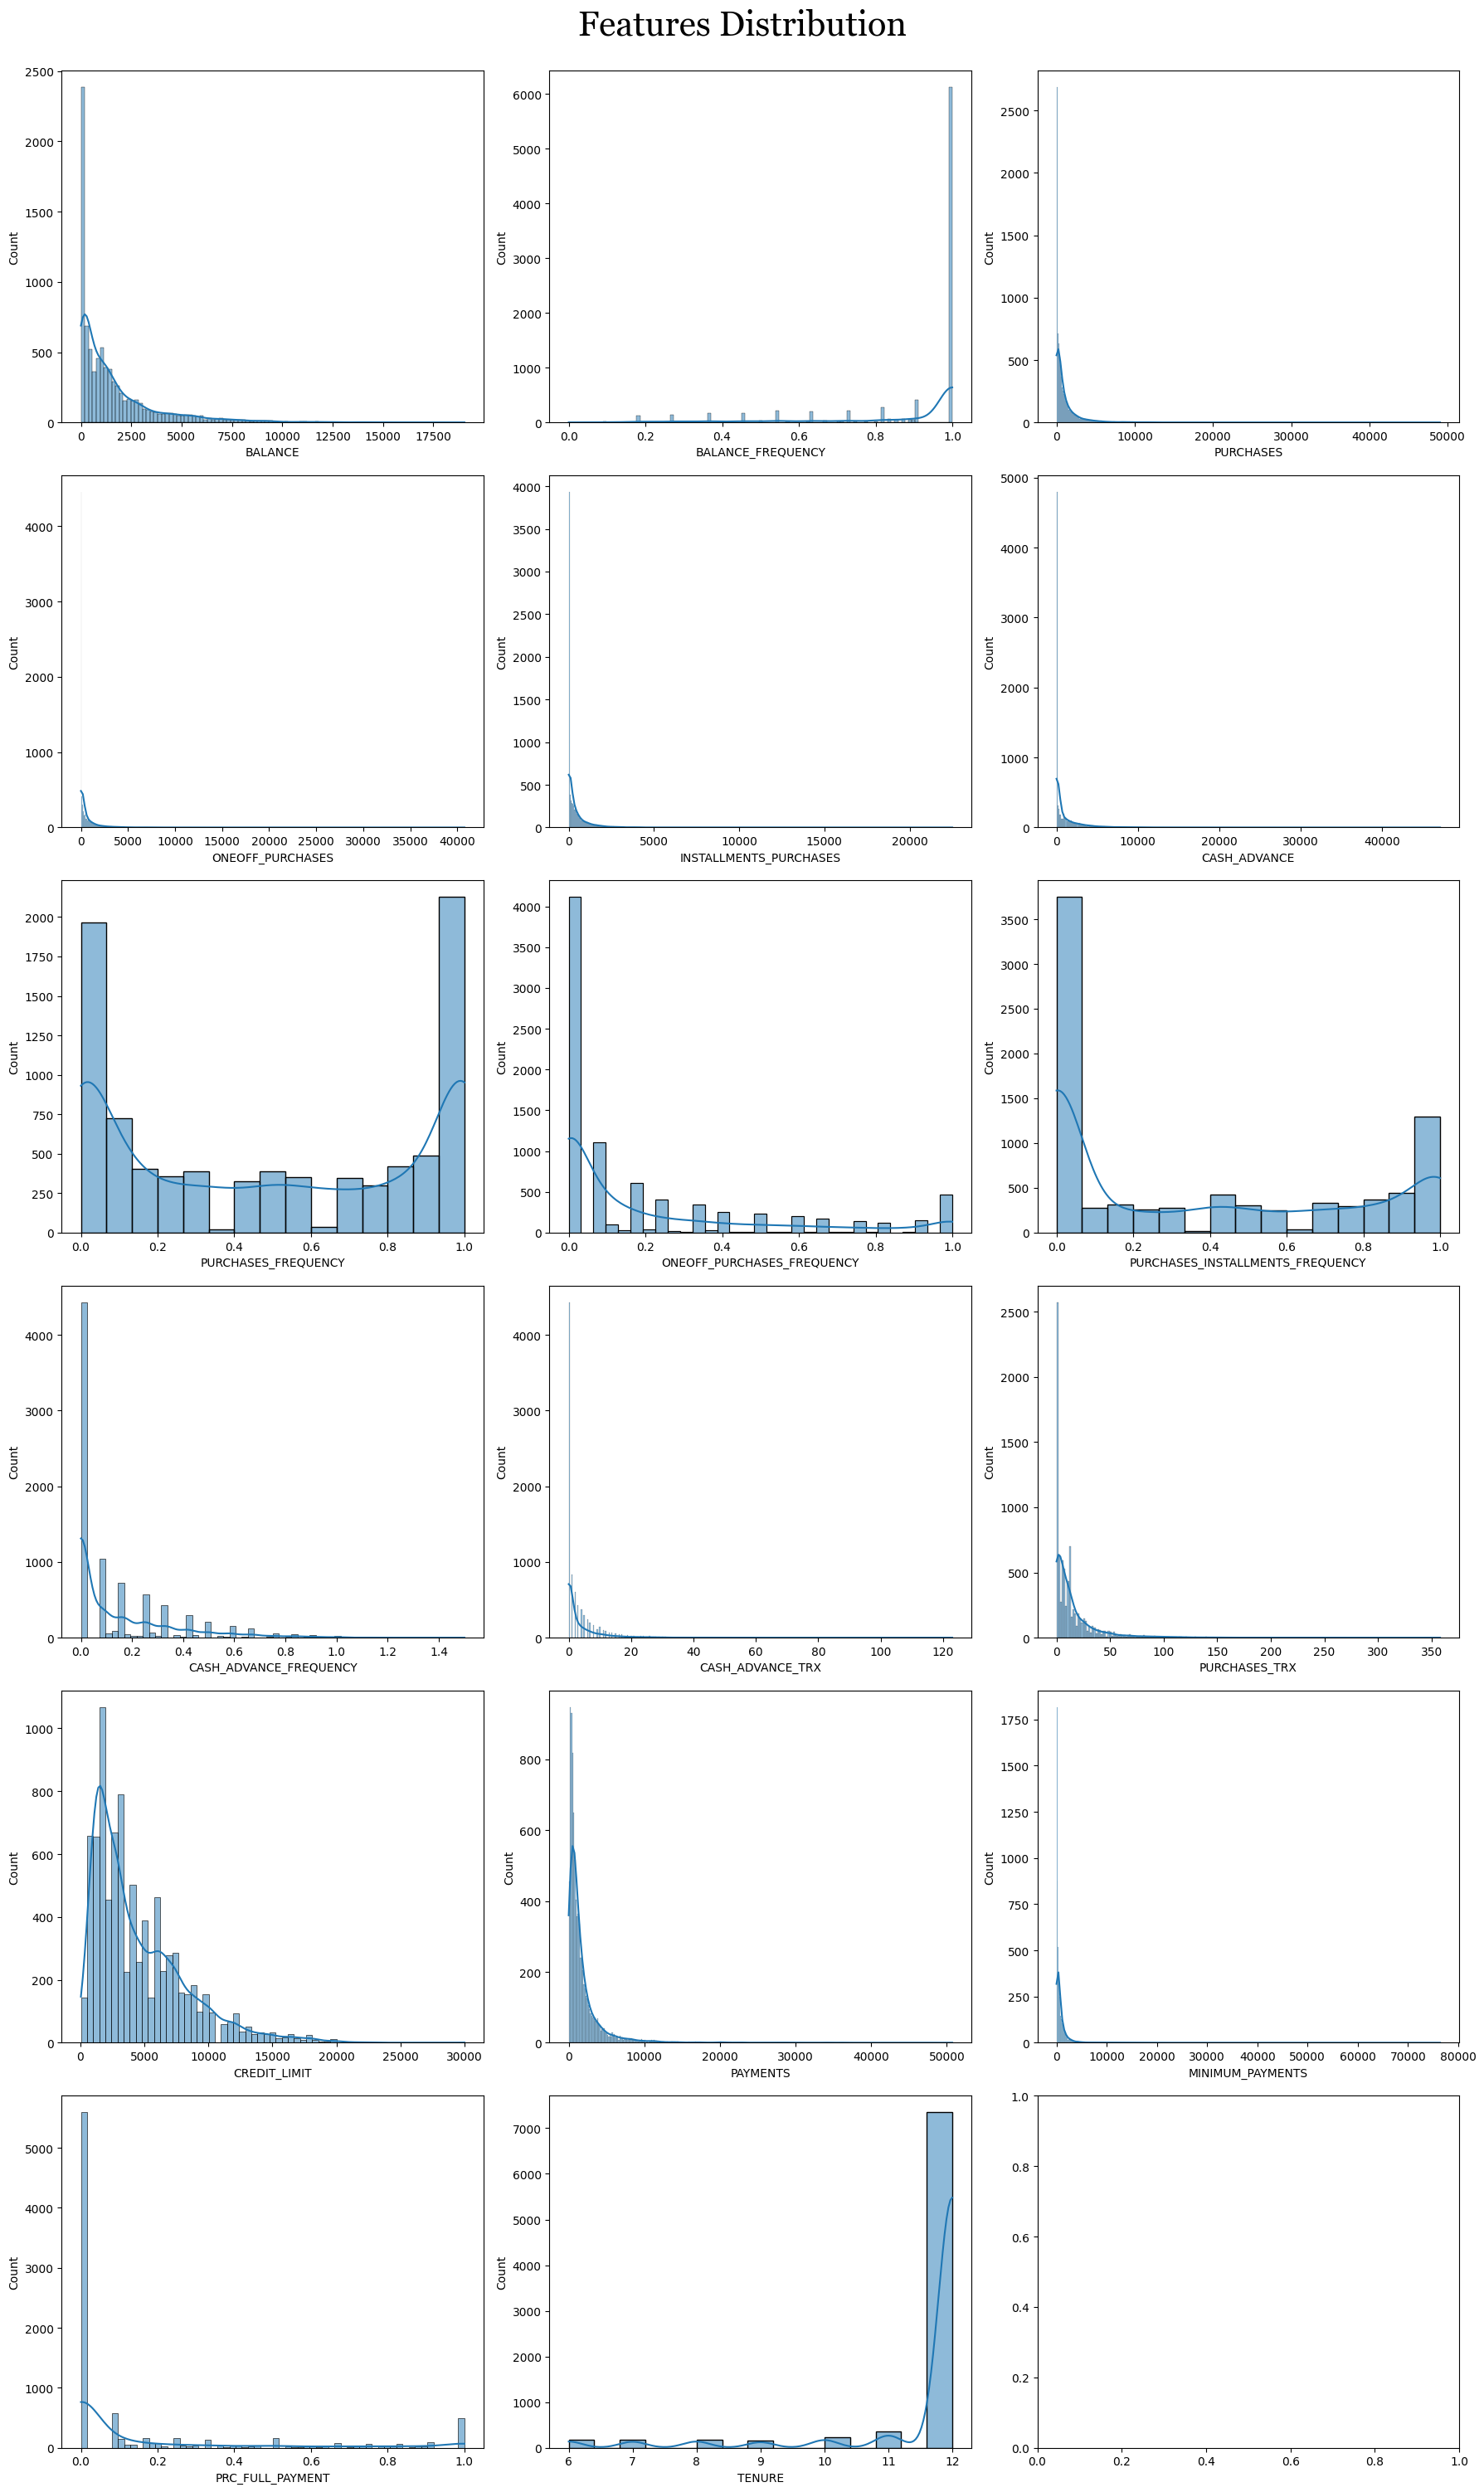

In [10]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(df.columns)+1)/3), figsize=(18,5*round((len(df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[index])
plt.suptitle('Features Distribution', font='georgia', fontsize=30, y=1)
plt.tight_layout()
plt.show()

<h4><font face=verdona><hr>Normalization using Log <hr>
As the data is skewed I will use Log transformation to Normalize the data

In [11]:
log_cols = list()
for col in df.columns:
    if (not(df[col].min() == 0 and df[col].max() == 1) and (col!='TENURE')) :
        log_cols.append(col)

log_cols

['BALANCE',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS']

In [12]:
log_transformed_df = df.copy()
for col in log_cols:
        log_transformed_df[col] = np.log(1 + log_transformed_df[col])

# log_transformed_df['TENURE'] = log_transformed_df['TENURE'].astype(int)
print(log_transformed_df.shape)
log_transformed_df.head()

(8636, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12
5,7.501540,1.000000,7.196147,0.000000,7.196147,0.000000,0.666667,0.000000,0.583333,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,12


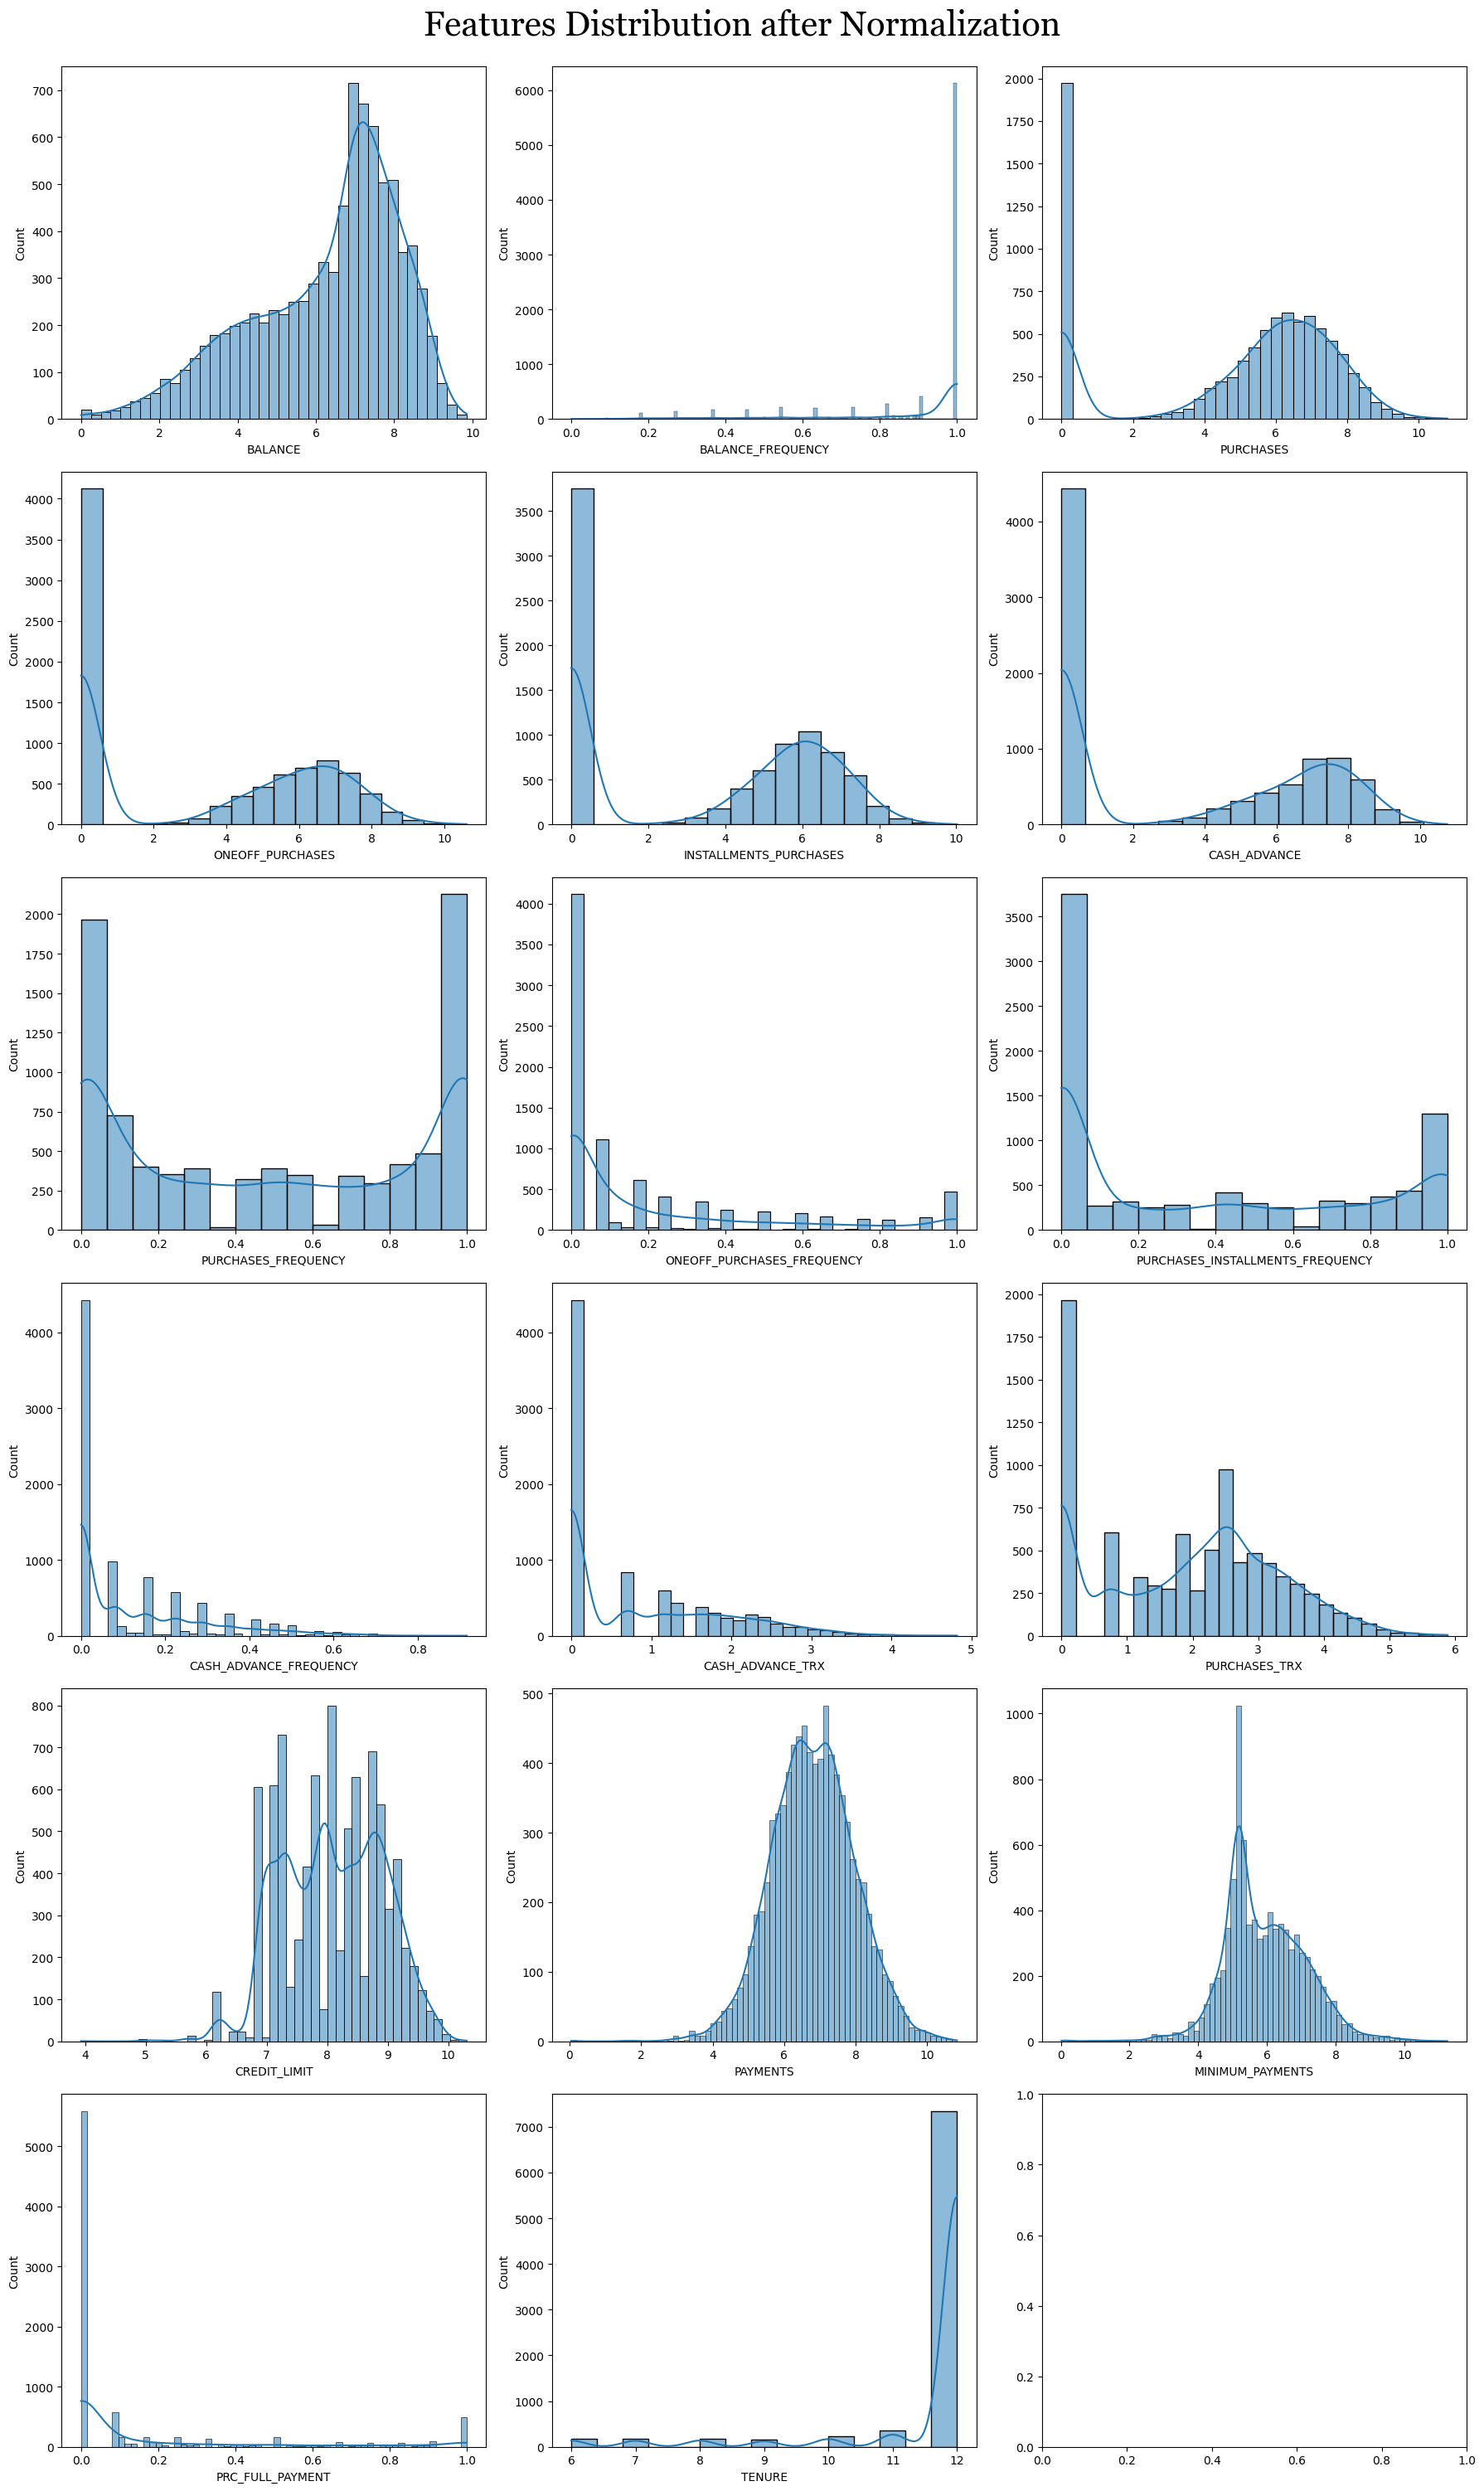

In [13]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(log_transformed_df.columns)+1)/3), 
                       figsize=(18,5*round((len(log_transformed_df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(log_transformed_df.columns):
    sns.histplot(log_transformed_df[col], kde=True, ax=axes[index])
plt.suptitle('Features Distribution after Normalization', font='georgia', fontsize=30, y=1)
plt.tight_layout()
plt.show()

In [14]:
def lb_ub(data, col):
    upper_b = np.percentile(data[col], 99.7)
    lower_b = np.percentile(data[col], 0.3)
    return lower_b, upper_b

lb_values = []
ub_values = []

for feature in df.columns:
    lb, ub = lb_ub(df, feature)
    lb_values.append(lb)
    ub_values.append(ub)

In [ ]:
pairplot = sns.pairplot(df)
plt.suptitle('Lower and upper bound visualization for outliers', y=1.02) 
for row in range(len(df.columns)):
    for col in range(len(df.columns)):
        pairplot.axes[row, col].axvline(x=lb_values[col], color='red', linestyle='--', linewidth=1)
        pairplot.axes[row, col].axvline(x=ub_values[col], color='red', linestyle='--', linewidth=1)
        pairplot.axes[row, col].axhline(y=lb_values[row], color='red', linestyle='--', linewidth=1)
        pairplot.axes[row, col].axhline(y=ub_values[row], color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

<h4><font face=verdona><hr>Outlier Handling <hr>The data seems to have quite a few outliers but the outliers cannot be capped or trimmed as they might belong to a 
cluster

<h4><font face=verdona><hr>Handling Multi-collinearity<hr>

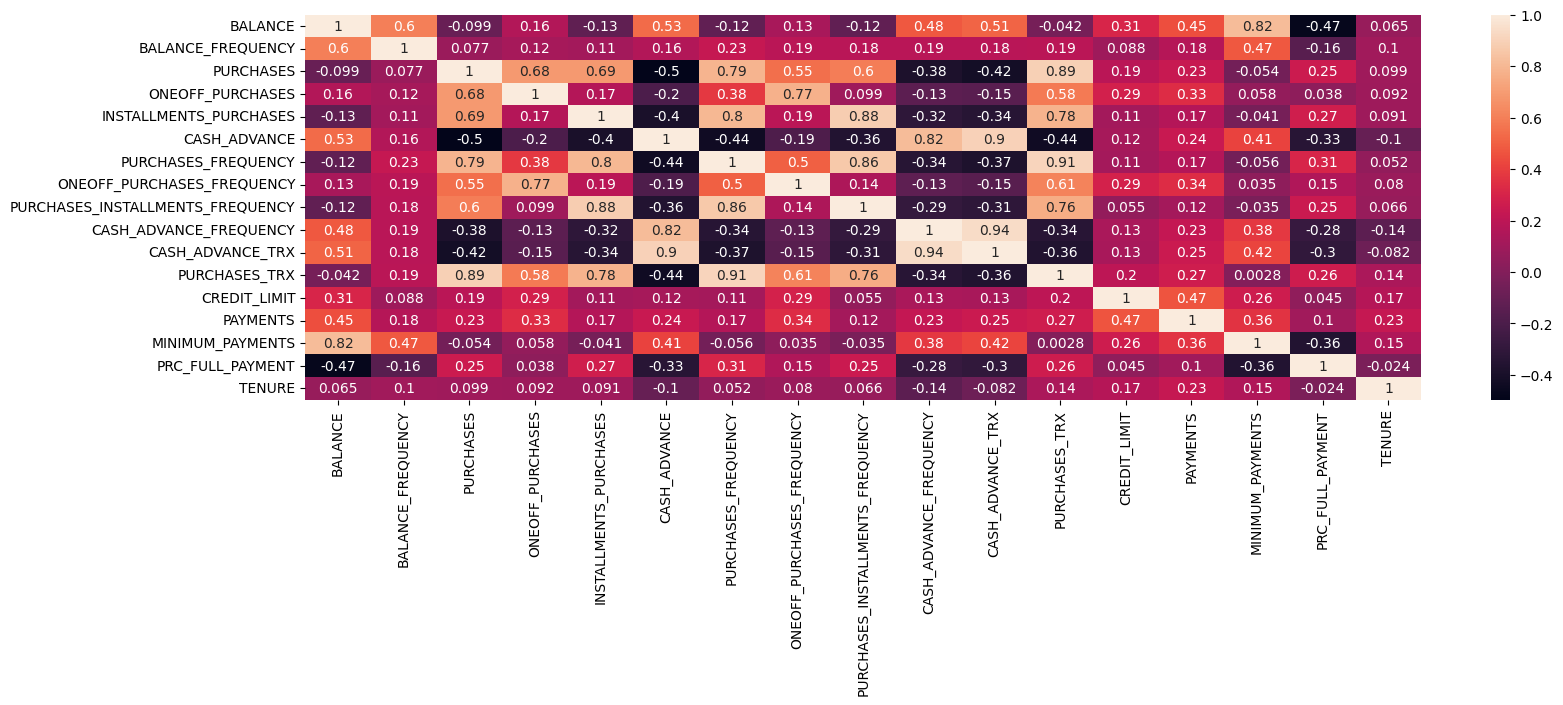

In [16]:
plt.figure(figsize=(18,5))
sns.heatmap(log_transformed_df.corr(), annot=True)
plt.show()

In [17]:
correlation_matrix = log_transformed_df.corr()

threshold = 0.9
highly_correlated_pairs = []

for i, col in enumerate(log_transformed_df.columns):
    for j in range(i + 1, len(log_transformed_df.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            highly_correlated_pairs.append((col, log_transformed_df.columns[j]))

new_s = set()
print("Pairs of columns with high correlation:")
for col1, col2 in highly_correlated_pairs:
    print(f"{col1} and {col2}: {correlation_matrix.loc[col1, col2]}")
    new_s.add(col1)
    # new_s.add(col2) 

Pairs of columns with high correlation:
PURCHASES_FREQUENCY and PURCHASES_TRX: 0.9088566850412443
CASH_ADVANCE_FREQUENCY and CASH_ADVANCE_TRX: 0.9375478996731024


In [18]:
data_new = log_transformed_df.drop(columns=list(new_s))

<h4><font face=verdona><hr>Using Explained Variance to determine the number of components<hr>

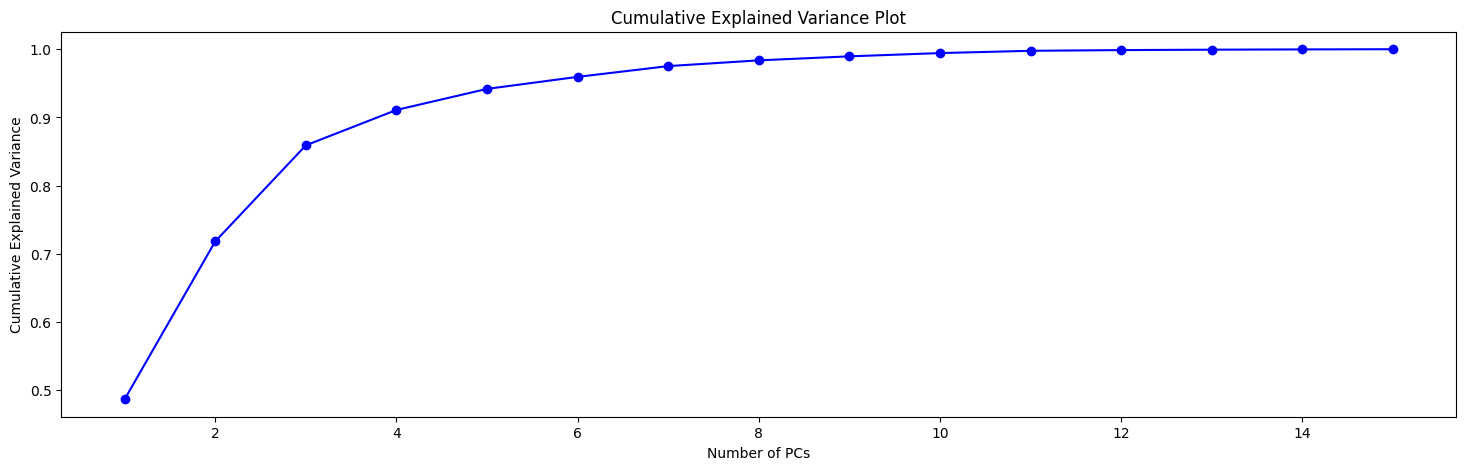

In [19]:
pca = PCA()
scaler = MinMaxScaler()
# scaled_df = scaler.fit_transform(data_new)
pca.fit(data_new)
cumulative_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(18, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance Plot')
plt.show()

In [20]:
cumulative_variance_threshold = 0.95
num_components = np.argmax(cumulative_variance >= cumulative_variance_threshold) 
num_components

np.int64(5)

In [21]:
scaler = MinMaxScaler()
pca = PCA(n_components=num_components)

In [22]:
# scaled_df = scaler.fit_transform(data_new)
pca_df = pca.fit_transform(data_new)
df_new = pd.DataFrame(pca_df)
df_new.head()

,0,1,2,3,4
0,1.001356,-5.717601,0.581652,-0.326847,0.404910
1,-8.987615,1.318327,0.872456,1.152004,0.908660
2,2.591156,1.276963,-5.062127,2.398494,-0.683966
3,-1.250354,-2.852003,-3.912334,2.228952,-0.276676
4,3.364709,-2.722453,3.876504,3.145306,-0.935186


<h4><font face=verdona><hr>Using elbow method to determine the optimal number of clusters<hr>

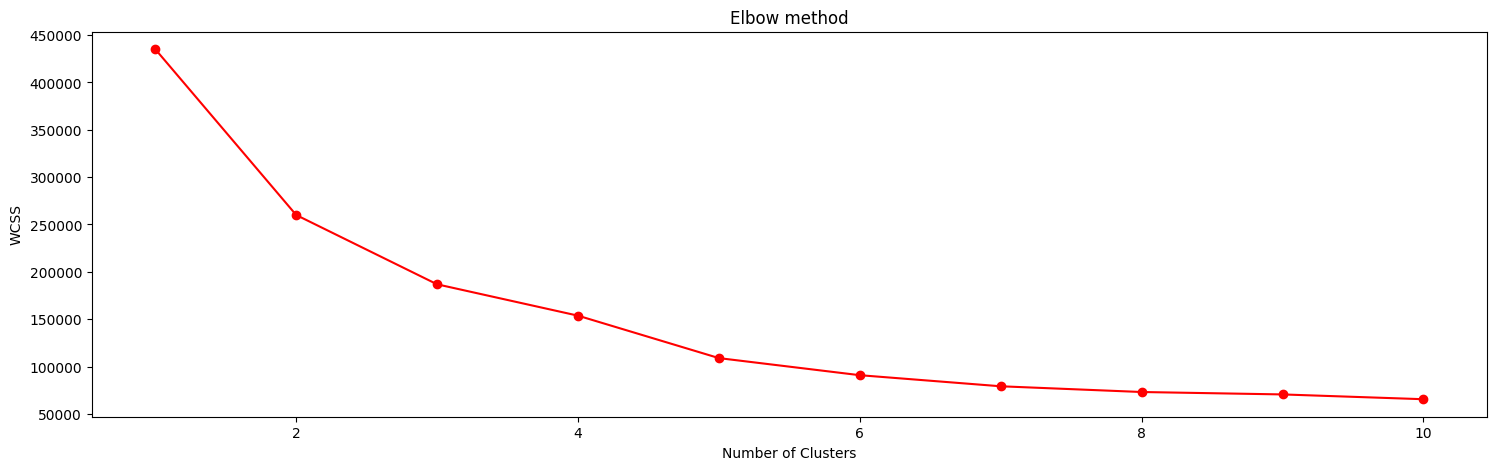

In [23]:
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')
kmeans_models = [KMeans(n_clusters=k,init='k-means++', random_state=42).fit(df_new) for k in range(1, 11)]
innertia = [model.inertia_ for model in kmeans_models]

plt.figure(figsize=(18,5))
plt.plot(range(1, 11), innertia, "ro-")
plt.title('Elbow method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [24]:
innertia

[435027.10194037517,
 259967.503133979,
 186794.22432792222,
 153680.7752795294,
 108875.0659107484,
 90835.58391736374,
 79135.2470309793,
 73086.9819784569,
 70532.834385096,
 65470.06101235684]

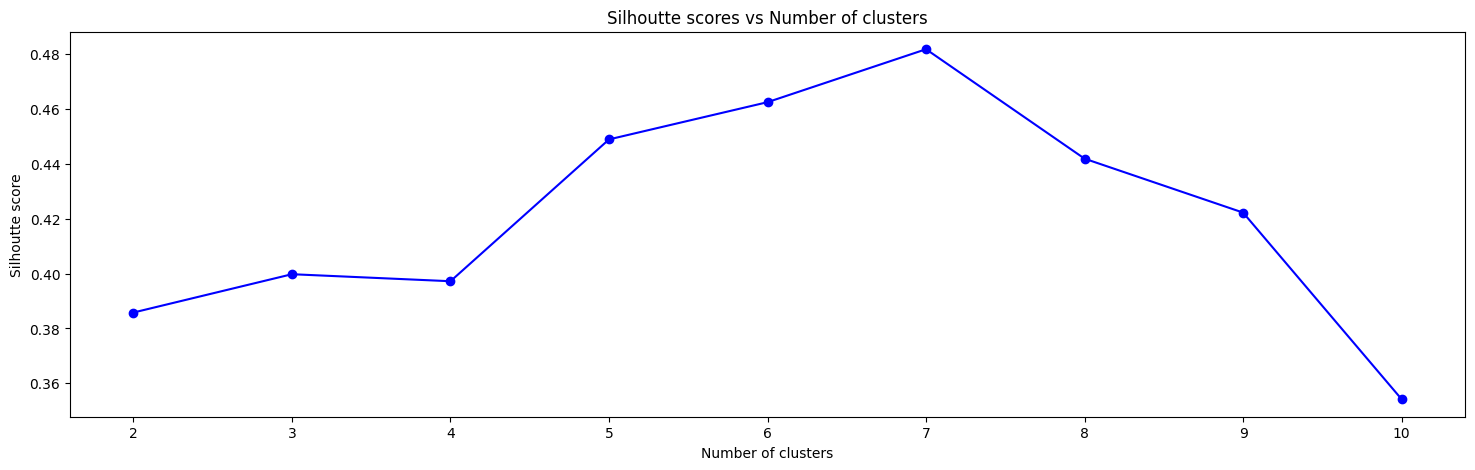

In [25]:
from sklearn.metrics import silhouette_score

plt.figure(figsize=(18,5))
silhoutte_scores = [silhouette_score(df_new, model.labels_) for model in kmeans_models[1:]]
plt.plot(range(2,11), silhoutte_scores, "bo-")
plt.title('Silhoutte scores vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte score')
plt.show()

In [26]:
silhoutte_scores

[np.float64(0.3857974318337605),
 np.float64(0.39975194771879013),
 np.float64(0.3971964231479866),
 np.float64(0.44884729470128537),
 np.float64(0.46240756166794134),
 np.float64(0.4816910861595731),
 np.float64(0.4418285649041087),
 np.float64(0.4221885395167815),
 np.float64(0.3542233339821857)]

<h4><font face=verdona><hr>As per visualization and for little more depth in customer segmentation 4 clusters would be optimal <hr>

<center><h1><font face=georgia color=magenta> Cluster Model Building (1)<br><font face=georgia color=yellow>Kmeans Clustering

In [28]:
kmeans = KMeans(n_clusters=5, n_init='auto',init='k-means++', random_state=42, max_iter=100)
kmeans_clusters = kmeans.fit_predict(df_new)
df_new['KMC_clusters'] = kmeans_clusters

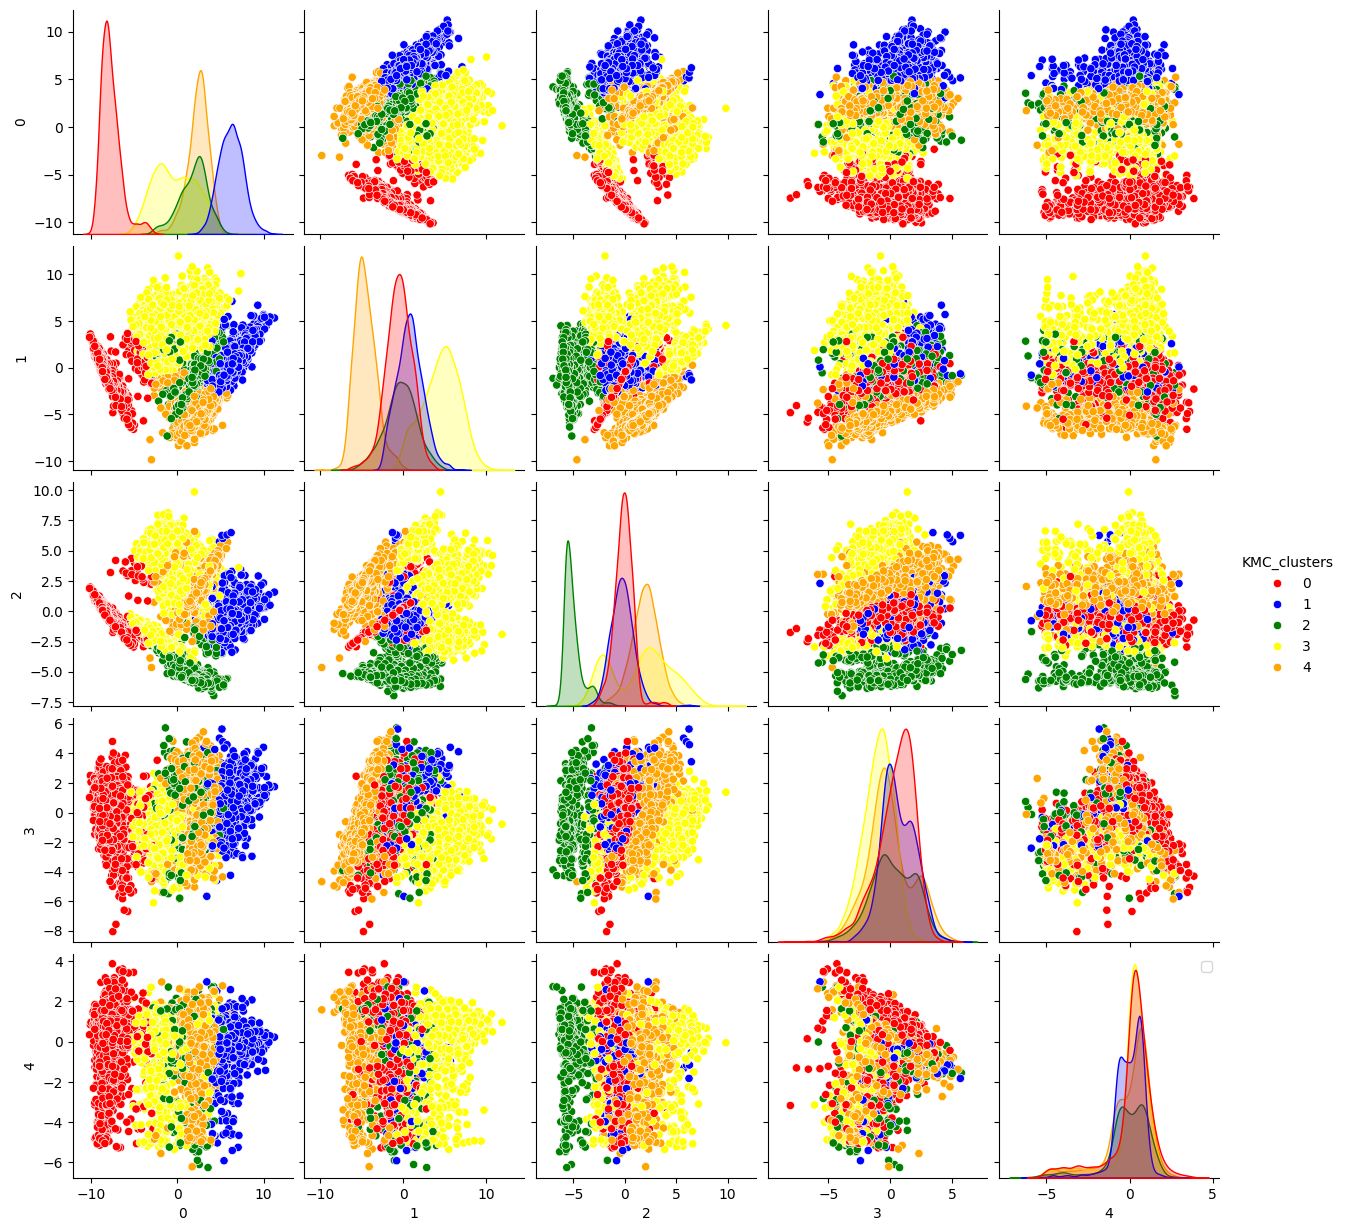

In [29]:
sns.pairplot(data=df_new, hue='KMC_clusters',palette=['red', 'blue', 'green', 'yellow','orange','magenta'])
plt.legend()
plt.show()

In [30]:
data_new['KMC_clusters'] = kmeans_clusters
data_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMC_clusters
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.000000,0.083333,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12,4
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12,0
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12,2
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12,2
5,7.501540,1.000000,7.196147,0.000000,7.196147,0.000000,0.000000,0.583333,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,12,4


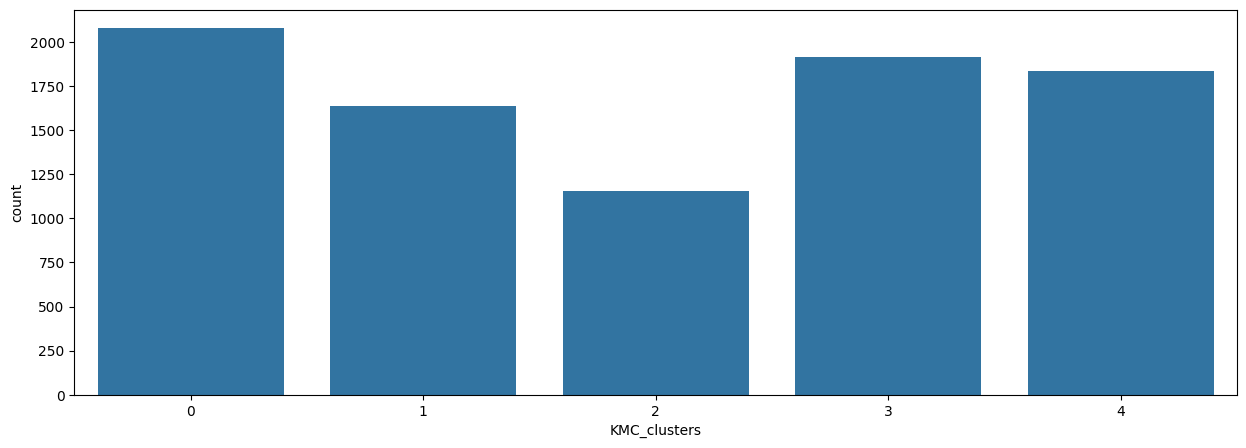

In [31]:
plt.figure(figsize=(15,5))
sns.countplot(x=data_new['KMC_clusters'])
plt.show()

<h4><font face=verdona><hr>Silhouette score (1)<hr>
KMeans Silsoutte score on original data (PCA not applied data)

In [32]:
silhouette_score(data_new.drop(columns=['KMC_clusters']), data_new['KMC_clusters'])

np.float64(0.4128707897126845)

<center><h1><font face=georgia color=magenta> Cluster Model Building (2)<br><font face=georgia color=yellow>Heirarchial Clustering 

In [33]:
pca2 = PCA(n_components=num_components)

pca_df_ = pca2.fit_transform(data_new)
df_new_ = pd.DataFrame(pca_df_)
df_new_.head()

,0,1,2,3,4
0,1.338735,-5.850675,0.746869,-0.816272,0.939752
1,-9.187493,1.279228,0.806331,1.436989,-0.560121
2,2.505576,1.428108,-5.021863,1.543273,2.305156
3,-1.256541,-2.778545,-3.934078,1.665259,1.296851
4,3.677219,-2.875392,3.935620,2.530768,2.558879


<h4><font face=verdona><hr>Plotting dendogram to get the optimal number of clusters<hr>

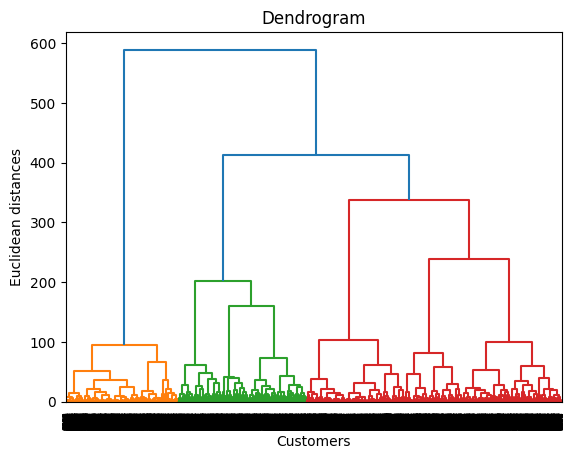

In [34]:
dendogram = sch.dendrogram(sch.linkage(pca_df_, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

<h4><font face=verdona><hr>According to the dendogram the longest line with no other line intervening directs us for 2 clusters but we will plot the silhoutte score against number of clusters from 1 to 10.<hr>

In [35]:
silhouette_scores = dict()
for i in range(2,11):
    agc = AgglomerativeClustering(n_clusters=i, metric='euclidean', linkage='ward')
    agc_clusters = agc.fit_predict(df_new_)
    silhouette_scores[i] = silhouette_score(df_new_, agc_clusters)

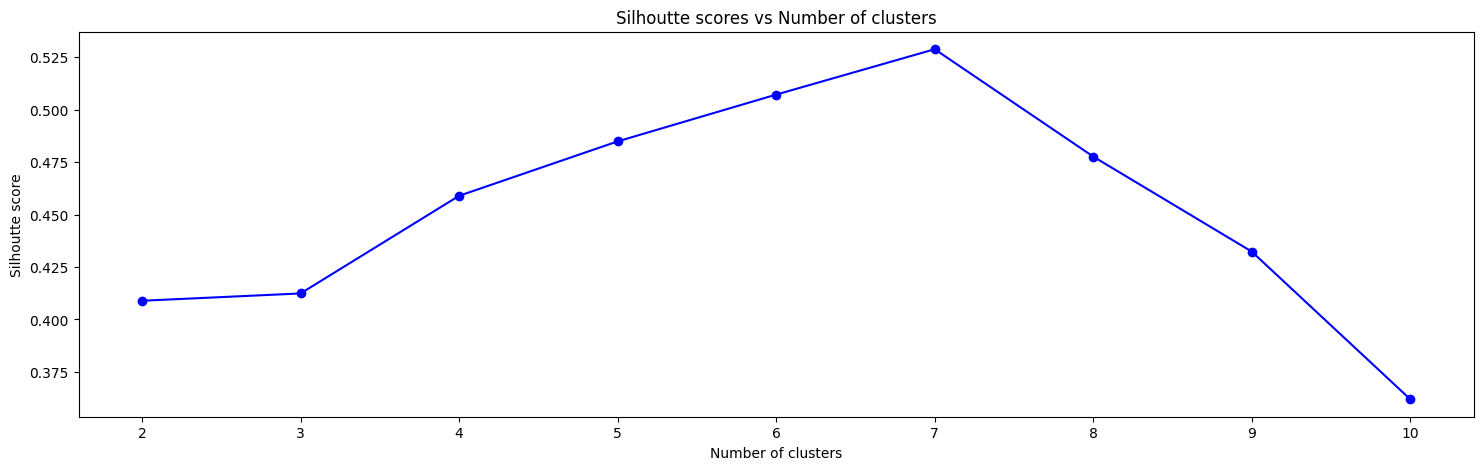

In [36]:
plt.figure(figsize=(18,5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), "bo-")
plt.title('Silhoutte scores vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte score')
plt.show()

<h4><font face=verdona><hr>
Setting clusters to 4 would be optimal as the jump in silhouette score is significant.<hr>

In [37]:
list(silhouette_scores.values())

[np.float64(0.40889923999227584),
 np.float64(0.41238463709633194),
 np.float64(0.4589358010770644),
 np.float64(0.4848741066954991),
 np.float64(0.5071858092096959),
 np.float64(0.5288188157516106),
 np.float64(0.47764304439191446),
 np.float64(0.4323421096938536),
 np.float64(0.3619525976066142)]

In [38]:
agc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
agc_clusters = agc.fit_predict(df_new_)
df_new_['Agc_clusters'] = agc_clusters

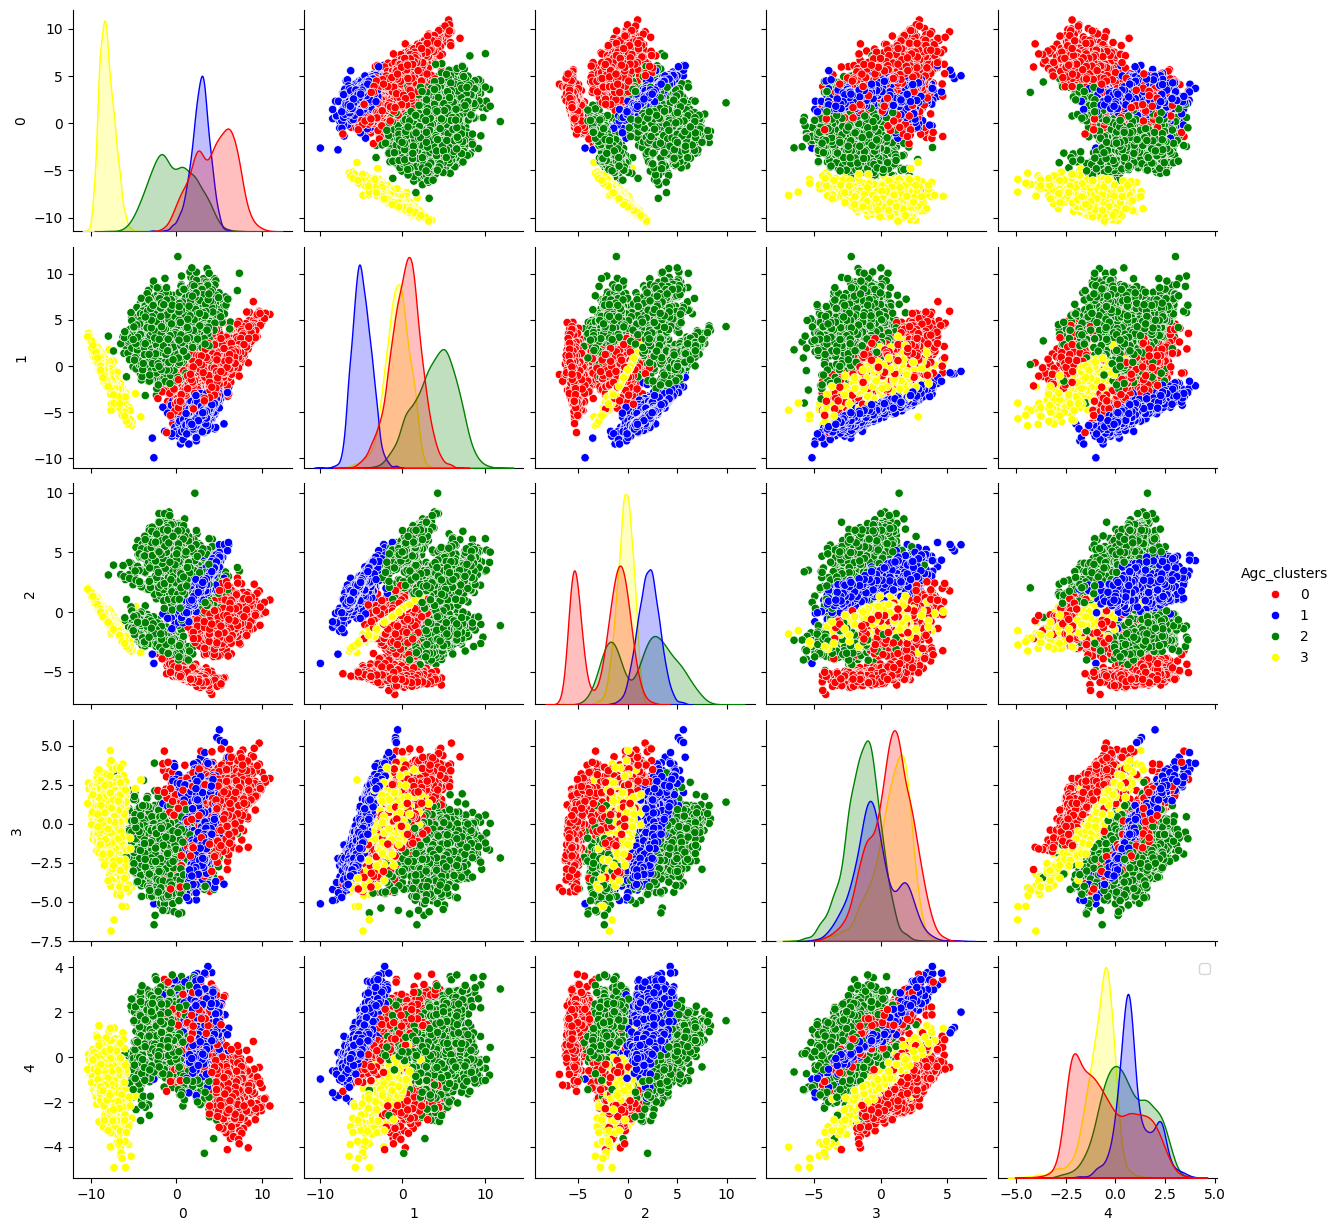

In [39]:
sns.pairplot(data=df_new_, hue='Agc_clusters',palette=['red', 'blue', 'green', 'yellow'])#,'orange','magenta'])
plt.legend()
plt.show()

In [40]:
data_new['Agc_clusters'] = agc_clusters
data_new.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMC_clusters,Agc_clusters
0,3.735304,0.818182,4.568506,0.000000,4.568506,0.000000,0.000000,0.083333,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12,4,1
1,8.071989,0.909091,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12,0,3
2,7.822504,1.000000,6.651791,6.651791,0.000000,0.000000,1.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12,2,0
4,6.707735,1.000000,2.833213,2.833213,0.000000,0.000000,0.083333,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12,2,0
5,7.501540,1.000000,7.196147,0.000000,7.196147,0.000000,0.000000,0.583333,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,12,4,1


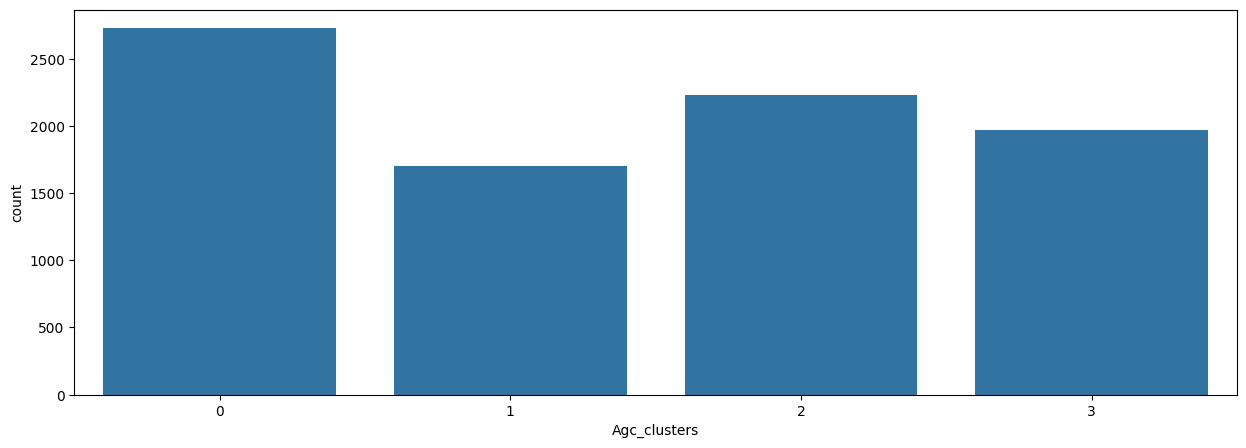

In [41]:
plt.figure(figsize=(15,5))
sns.countplot(x=data_new['Agc_clusters'])
plt.show()

<h4><font face=verdona><hr>Silhouette score (2)<hr>
Agc Silsoutte score on original data (PCA not applied data)

In [42]:
silhouette_score(data_new.drop(columns=['KMC_clusters','Agc_clusters']), data_new['Agc_clusters'])

np.float64(0.38312726283517035)

<h4><font face=verdona><hr>Comparing Clusters of both the Models<hr>

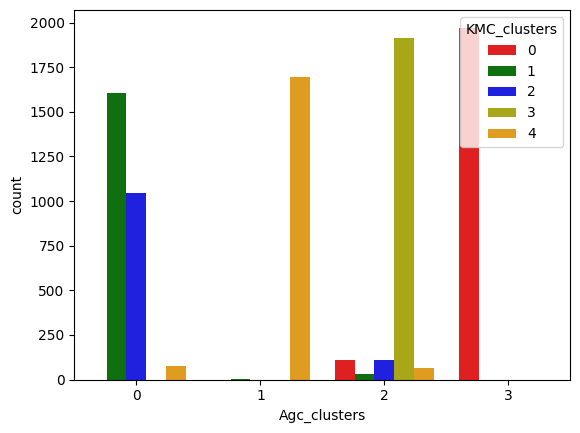

In [43]:
sns.countplot(x=data_new['Agc_clusters'], hue=data_new['KMC_clusters'], palette=['r','g','b','y','orange'])
plt.show()

<h4><font face=verdona><hr>
We can see The clusters of AGC and KMeans group similar records together i.e.
<br> AGC cluster 1 ~ KMeans cluster 4
<br>AGC cluster 2 ~ KMeans cluster 3
<br>AGC cluster 3 ~ KMeans cluster 0
<br>Agc cluster 0 ~ KMeans cluster 1 and 2<hr>

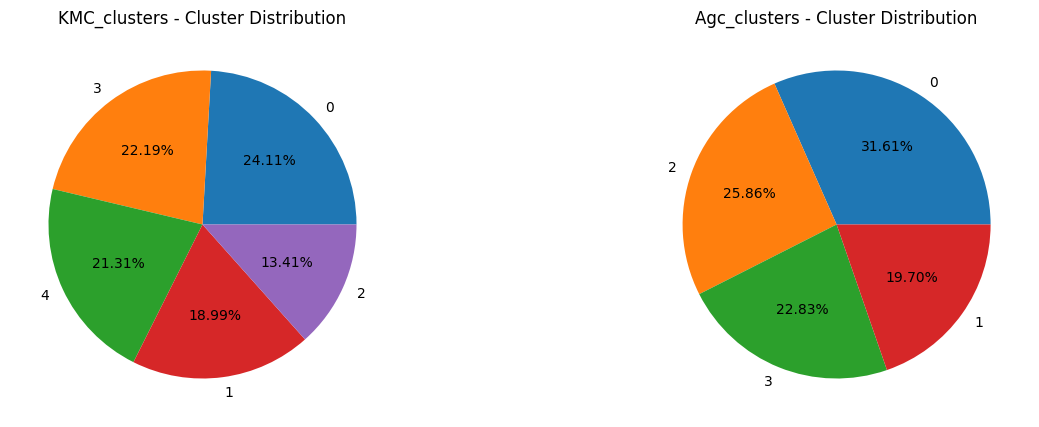

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axes = ax.flatten()
for index, col in enumerate(data_new.columns[-2:]):
    axes[index].set_title(f'{col} - Cluster Distribution')
    axes[index].pie(x=data_new[col].value_counts(),
        labels =data_new[col].value_counts().index[:], autopct='%.2f%%' )
plt.show()

<h4><font face=verdona><hr>Now I can visualize are the features' range that differenciate between clusters<hr>

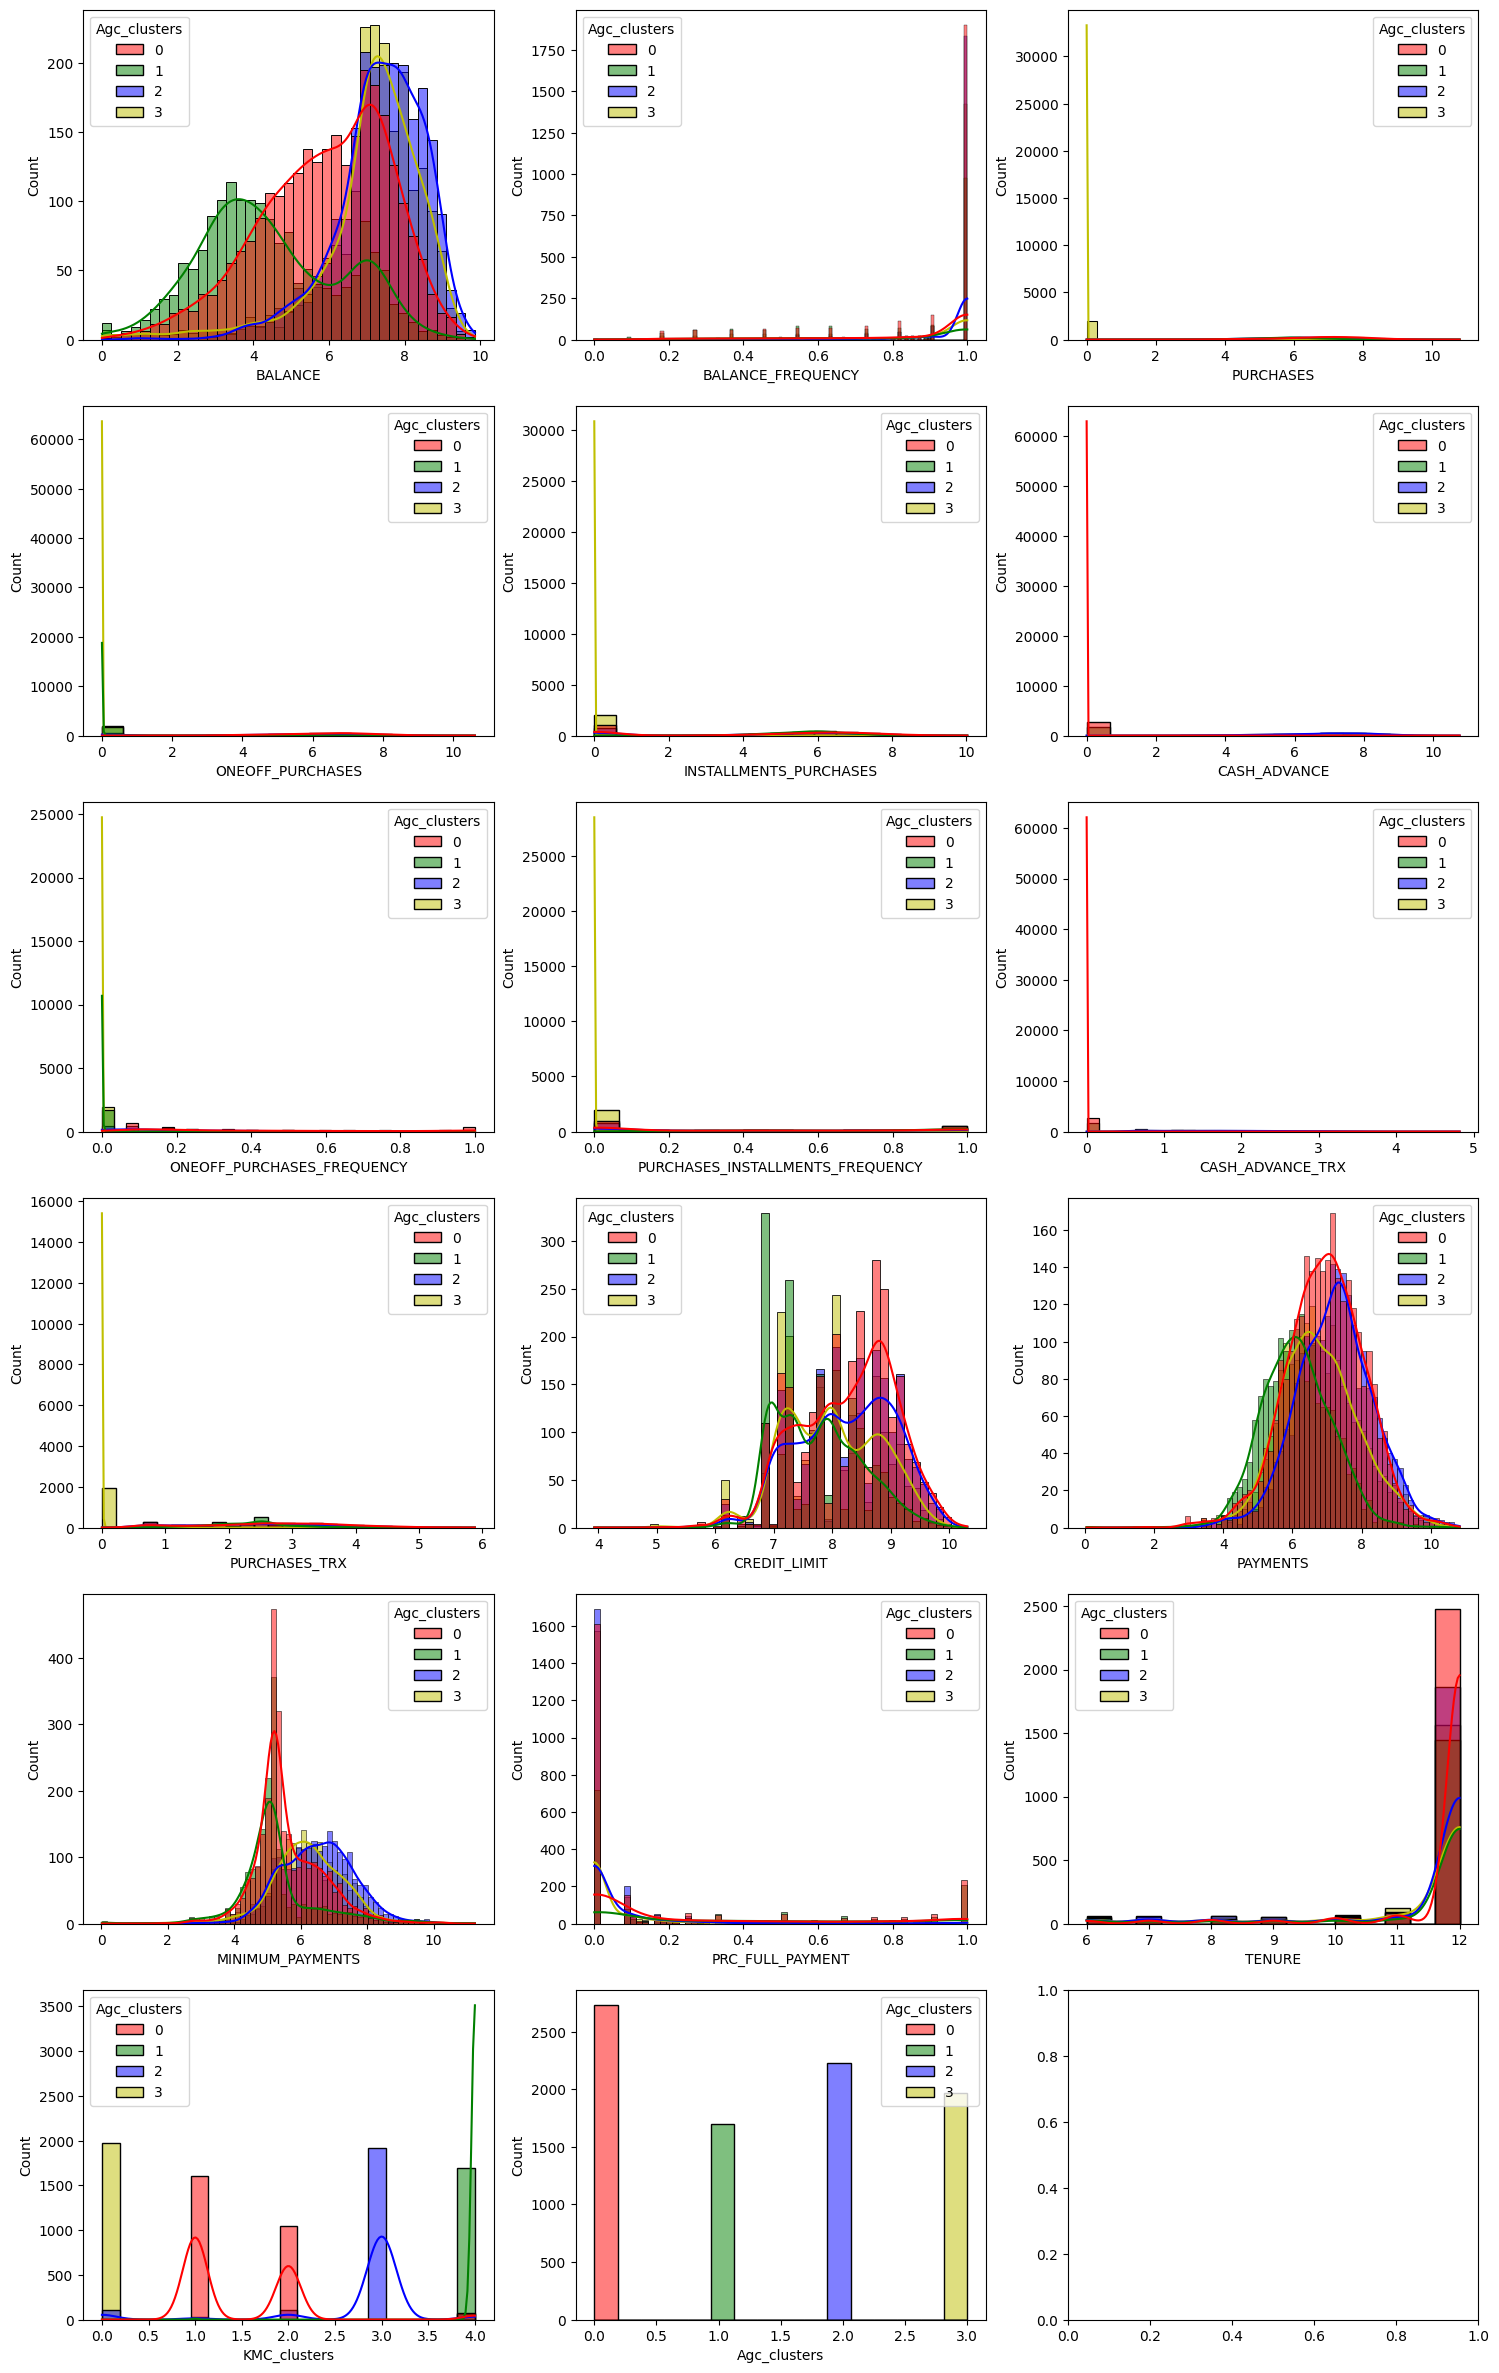

In [45]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(data_new.columns)+1)/3),
                       figsize=(18,5*round((len(data_new.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(data_new.columns):
    sns.histplot(x=data_new[col], hue=data_new['Agc_clusters'], kde=True, ax=axes[index],
                 hue_order=[0, 1, 2, 3],palette=['r', 'g', 'b', 'y'])

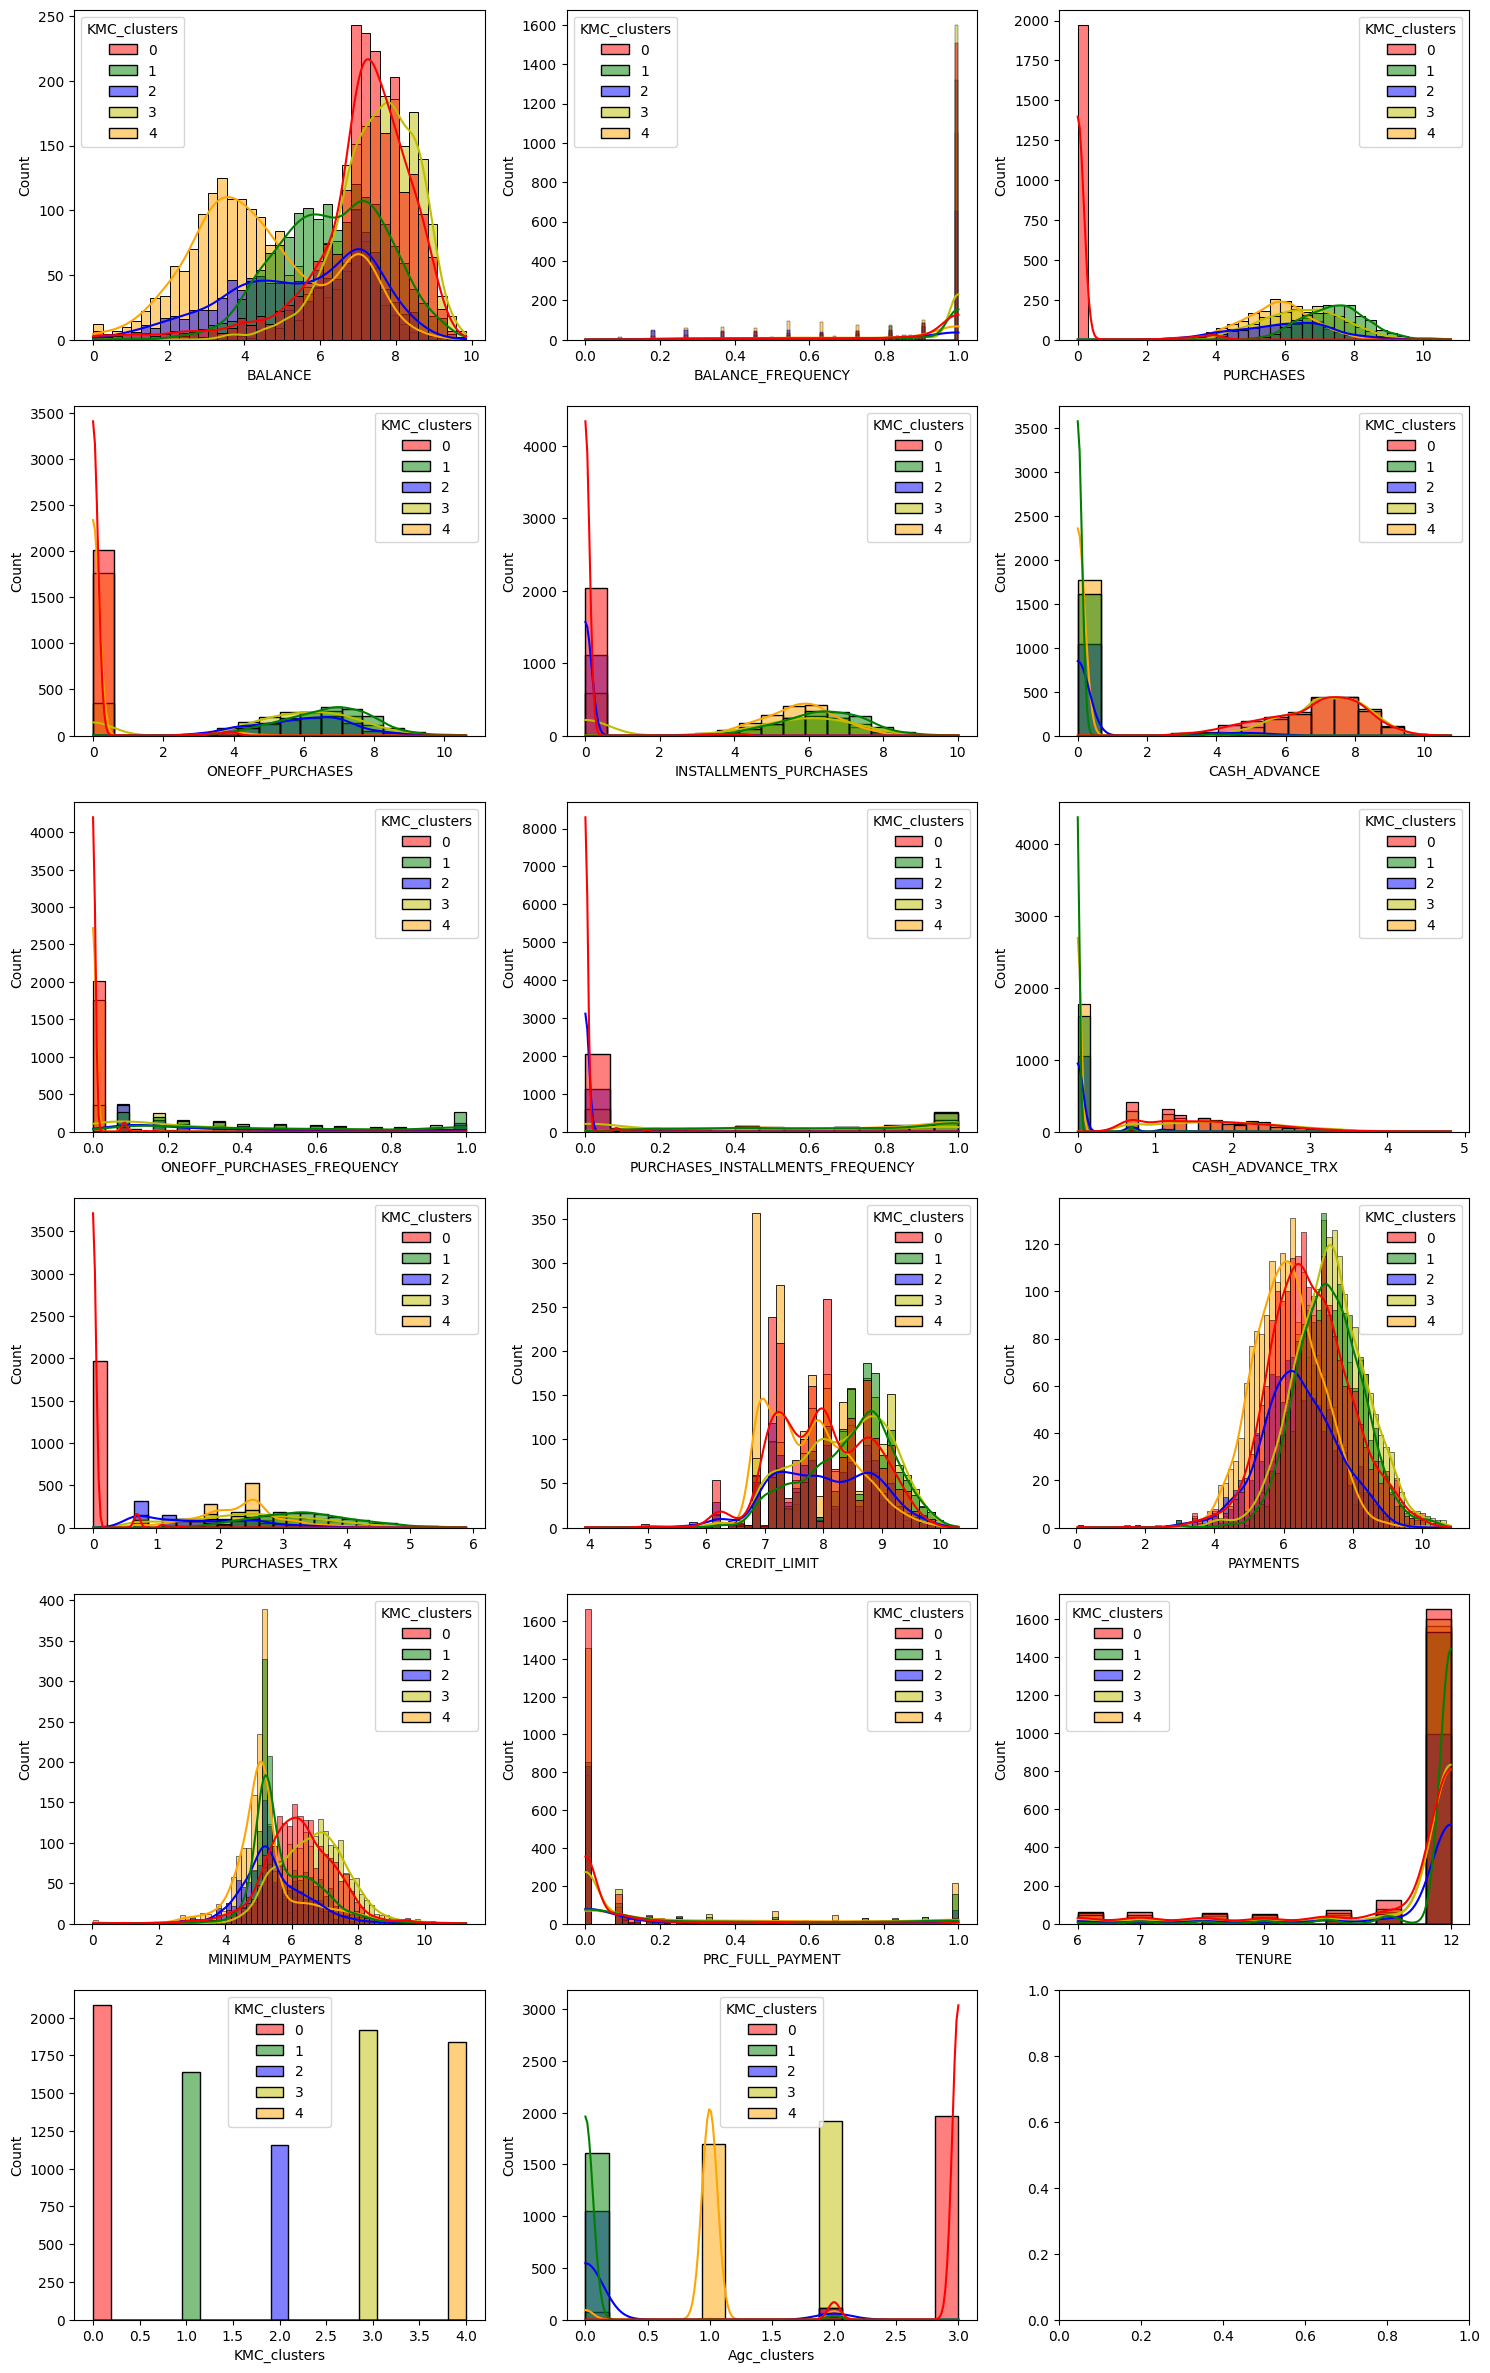

In [46]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(data_new.columns)+1)/3), figsize=(18,5*round((len(data_new.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(data_new.columns):
    sns.histplot(x=data_new[col], hue=data_new['KMC_clusters'], kde=True, ax=axes[index],
                 hue_order=[0,1,2,3,4],palette=['r','g','b', 'y', 'orange'])

<h3><font color=red face=verdona><center>Since KMC_clusters have a better silhoutte score and Also majorly the cluster are the same,<br>I will consider KMC_clusters as the target feature generated by KMeans

In [47]:
data_new.drop(columns=['Agc_clusters'], inplace=True)

<center><font color=magenta face=georgia><h1>Cluster based EDA

<h4><font face=verdona><hr>As I havent dropped any rows the indices remain the same as raw data thus can assign the clusters to the original data<hr>

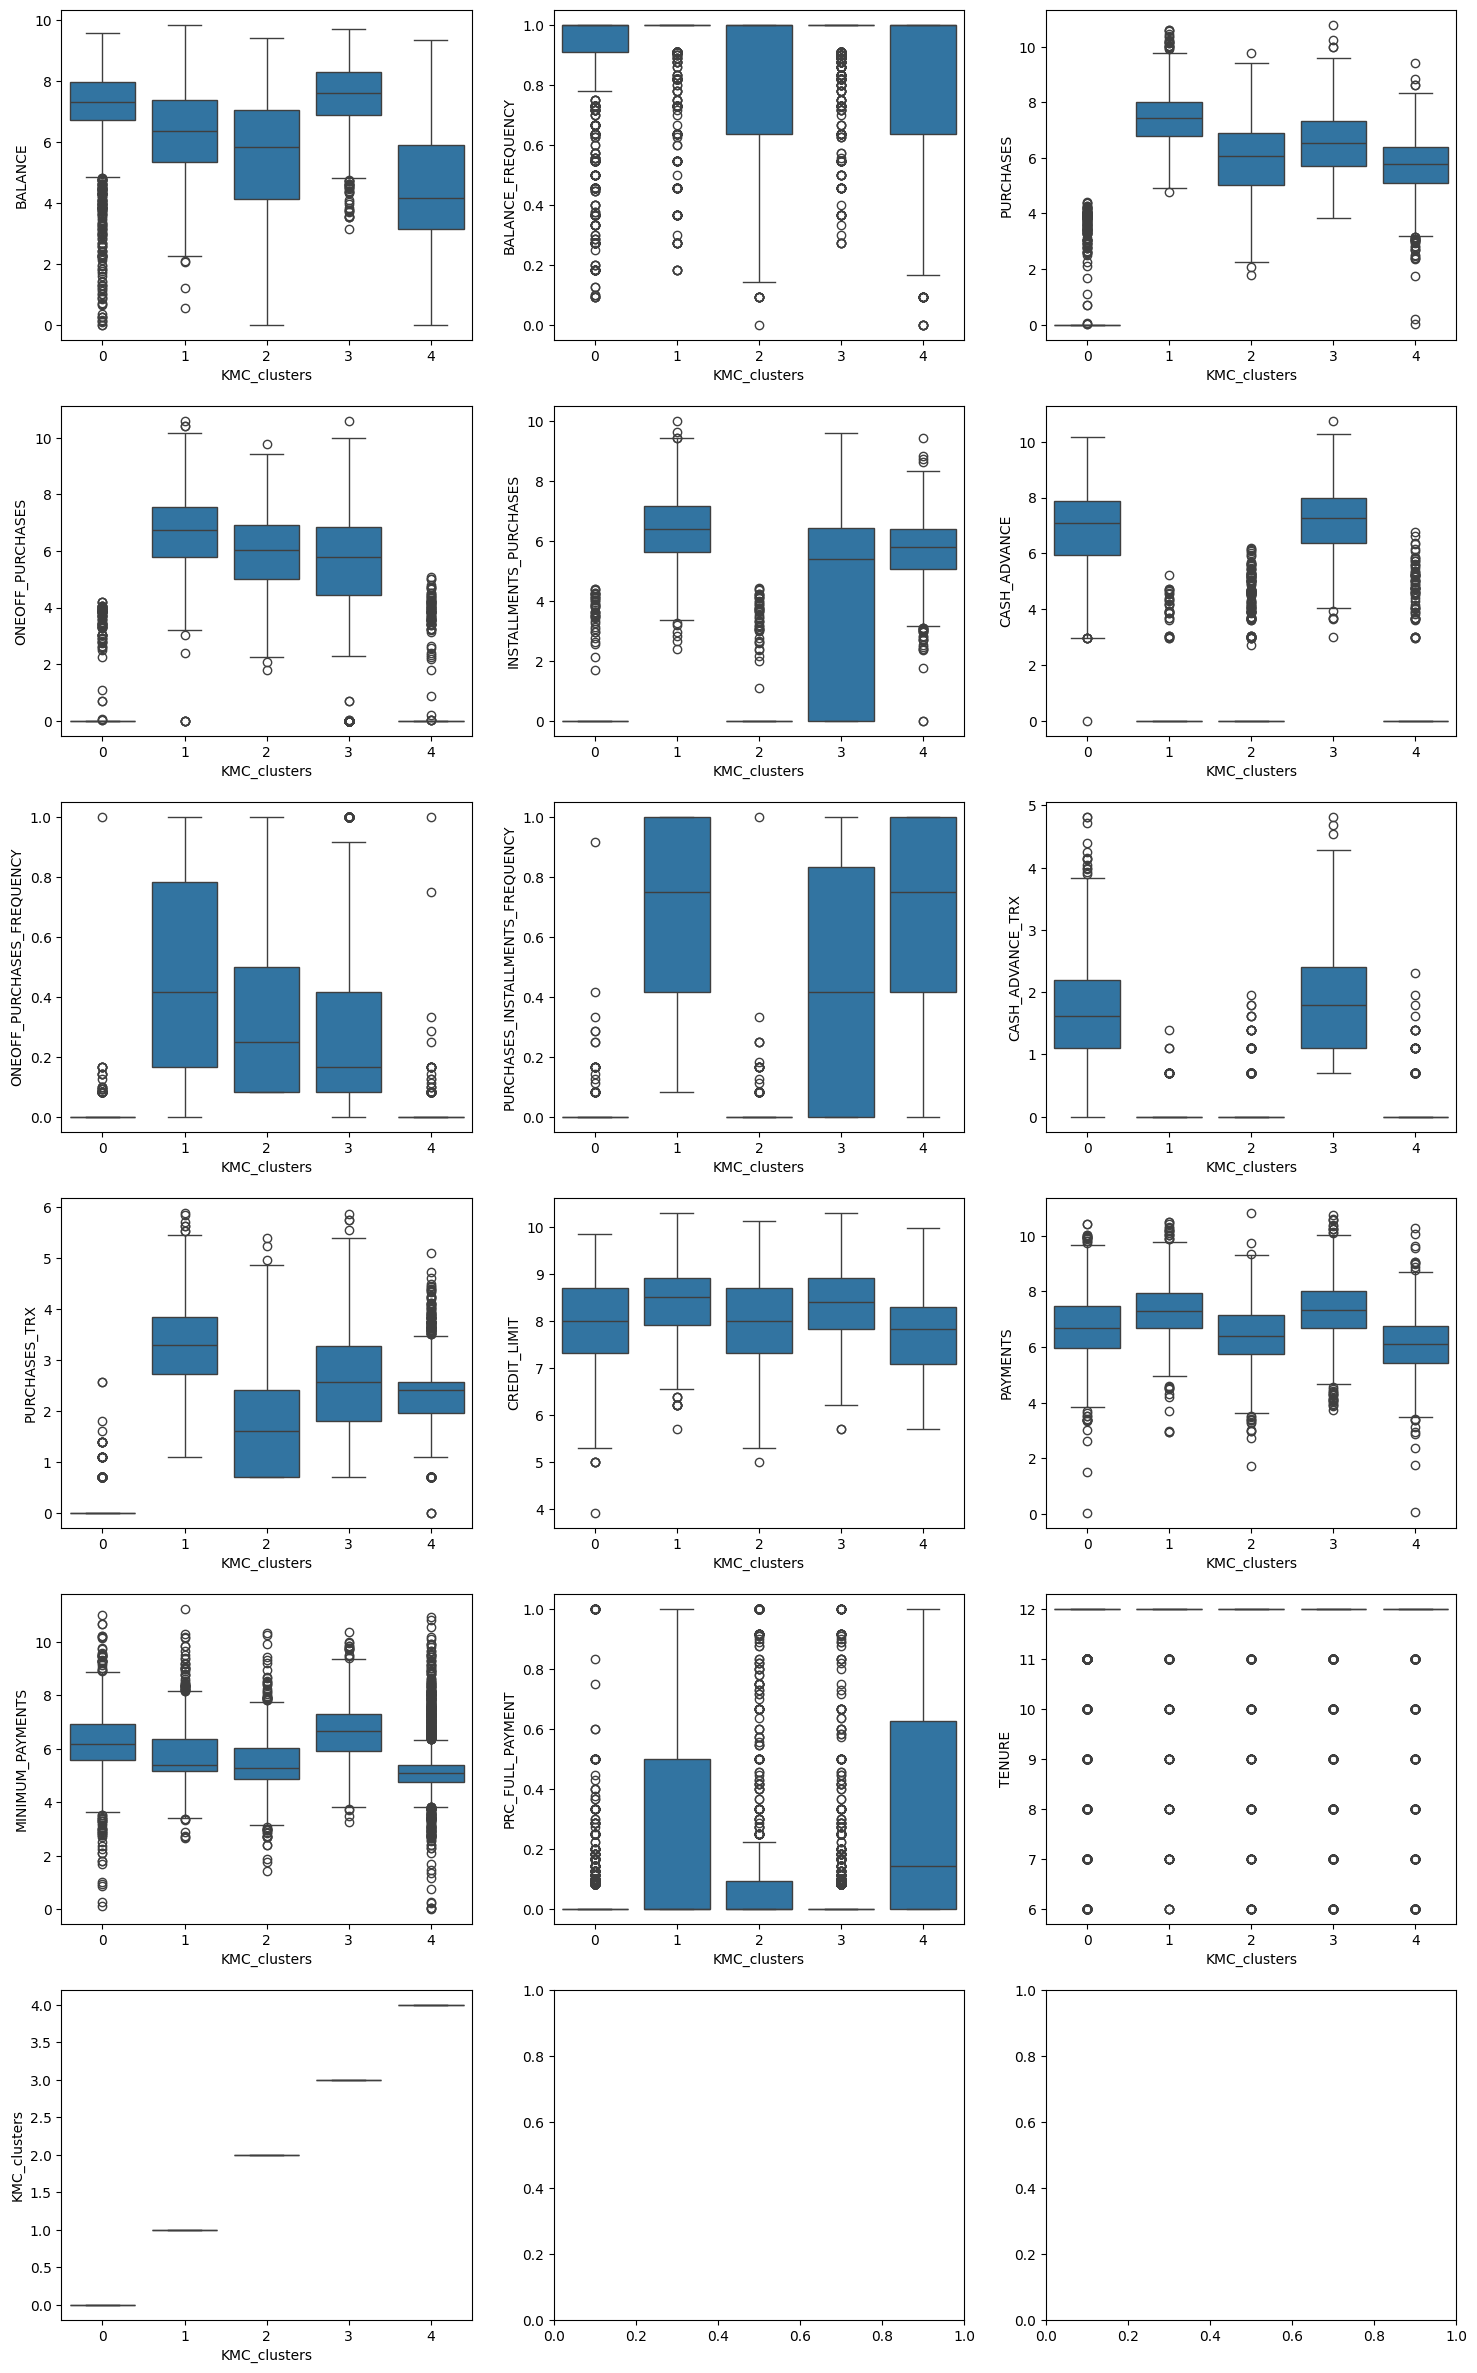

In [48]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(data_new.columns)+1)/3), figsize=(18,5*round((len(data_new.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(data_new.columns):
    sns.boxplot(x=data_new['KMC_clusters'], y=data_new[col], ax=axes[index])

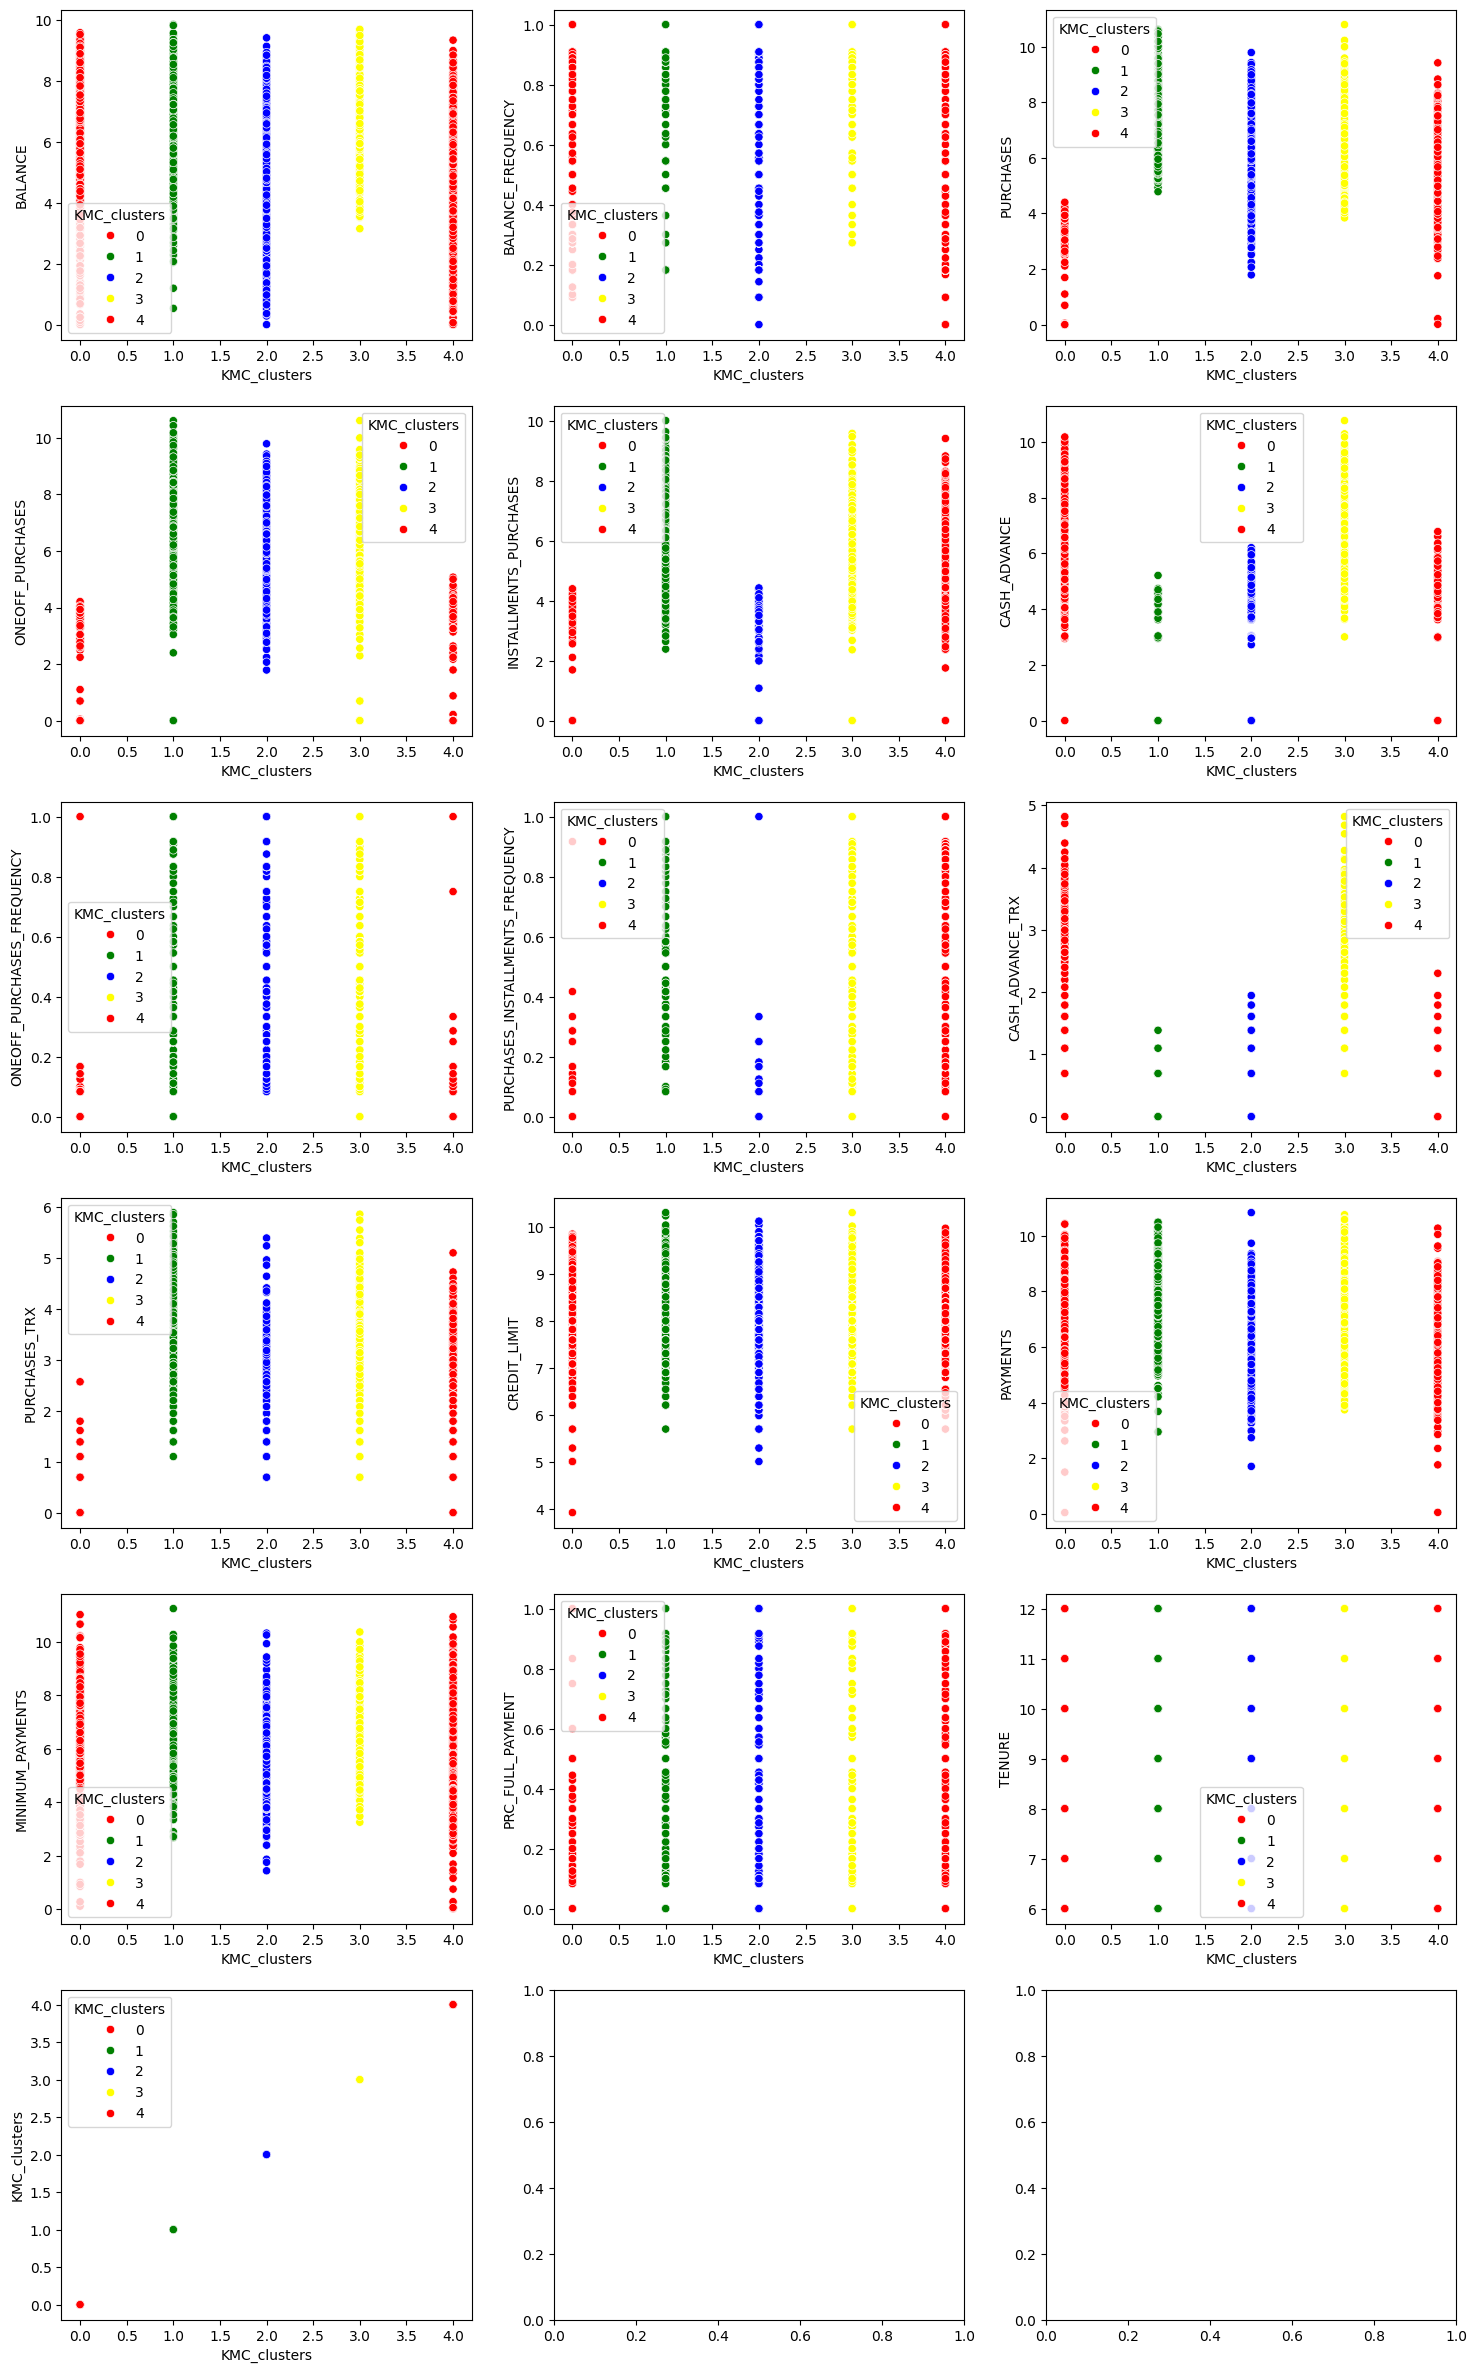

In [49]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(data_new.columns)+1)/3), figsize=(18,5*round((len(data_new.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(data_new.columns):
    sns.scatterplot(data=data_new, x='KMC_clusters', y=col, ax=axes[index], hue='KMC_clusters', palette=['red', 'green', 'blue', 'yellow'])

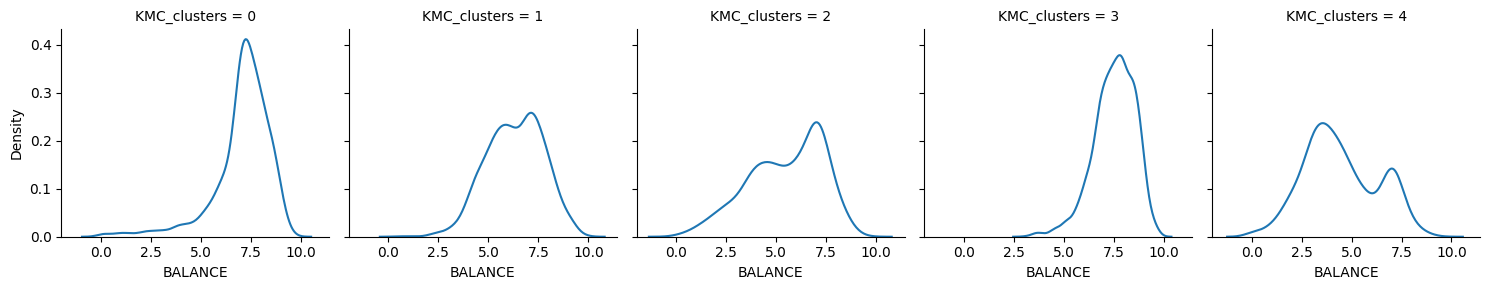

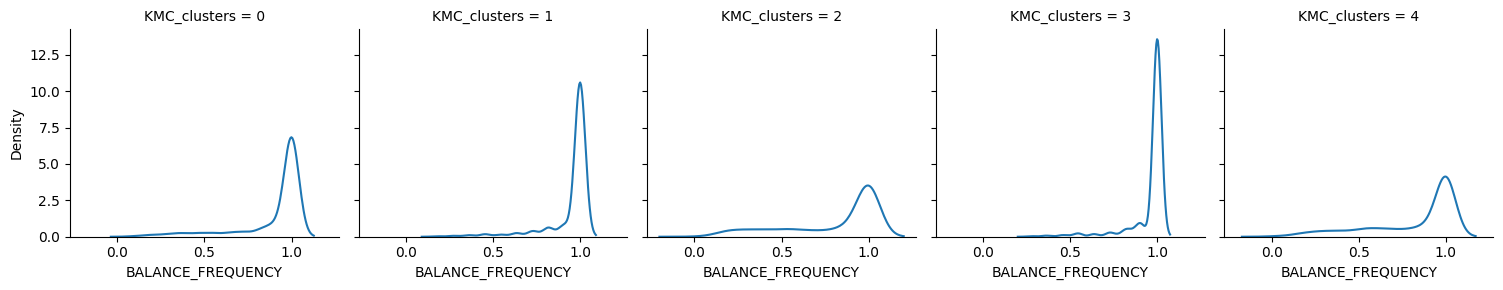

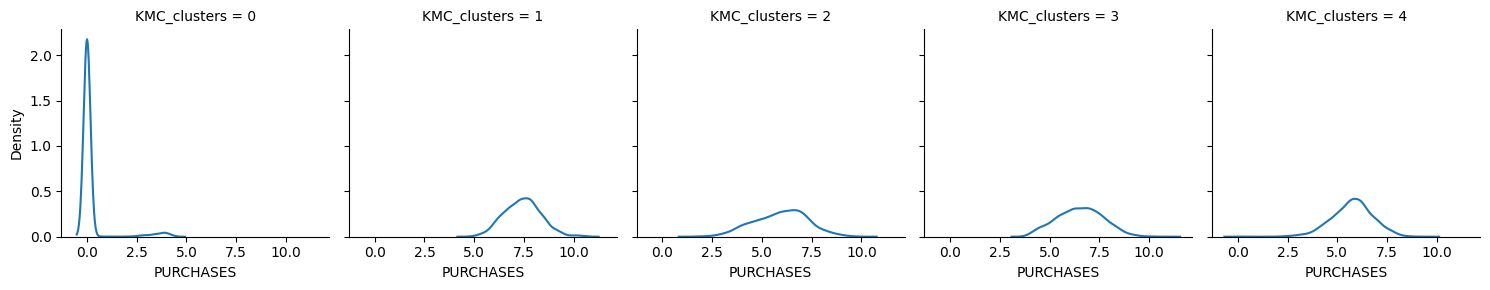

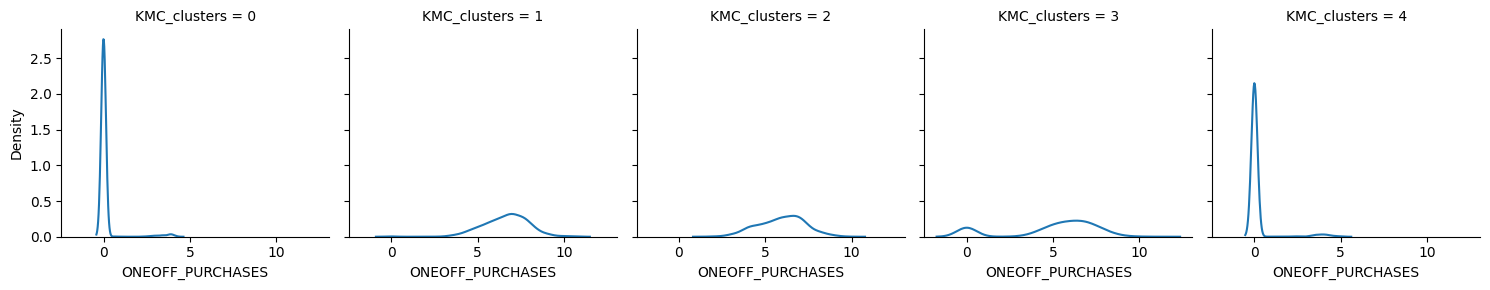

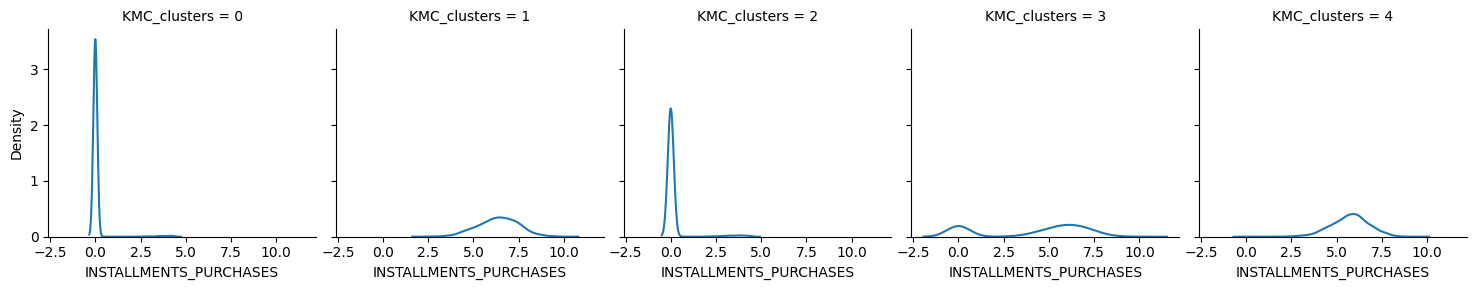

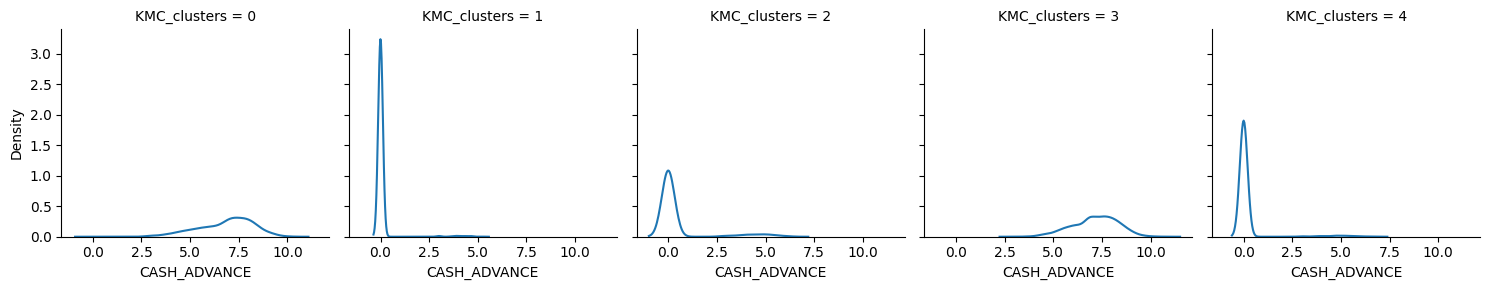

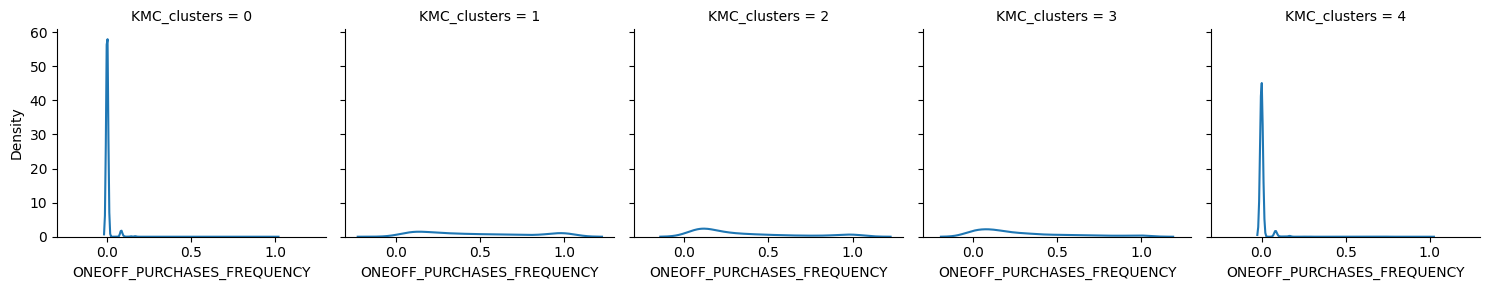

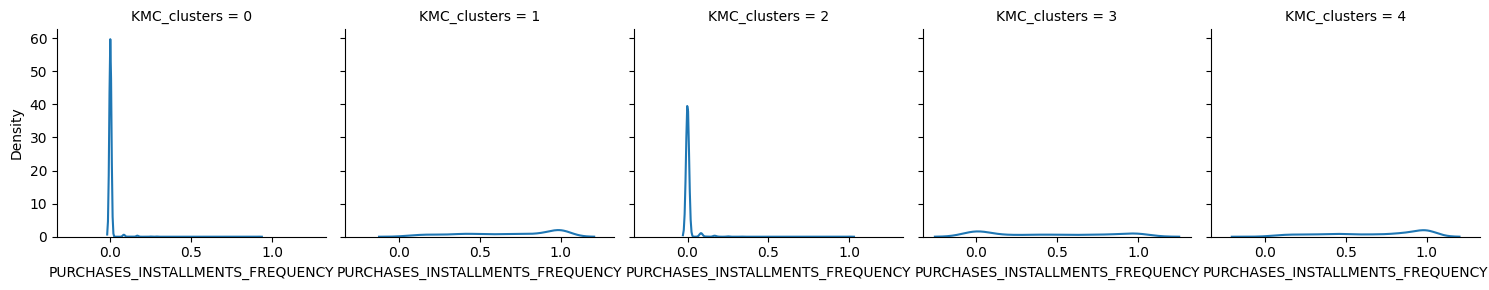

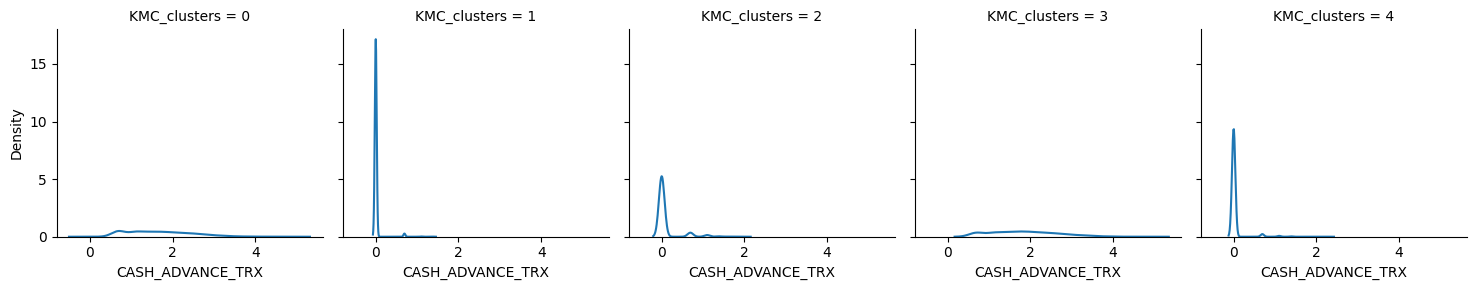

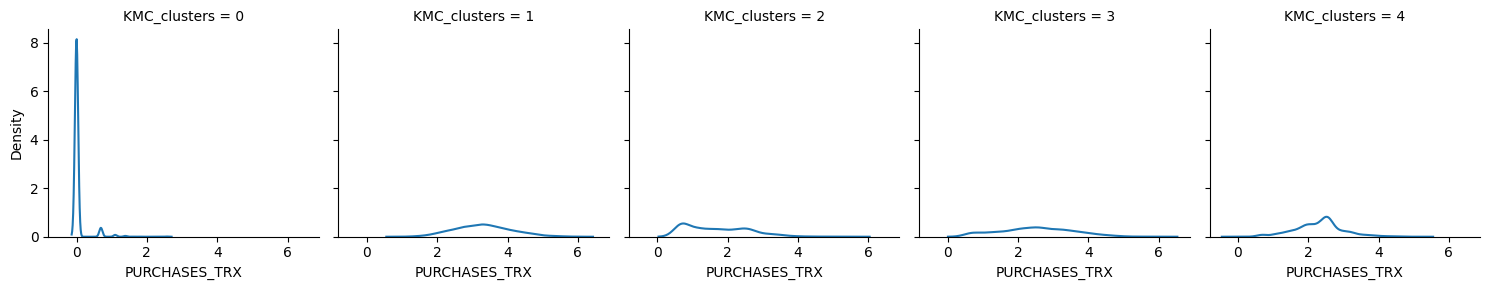

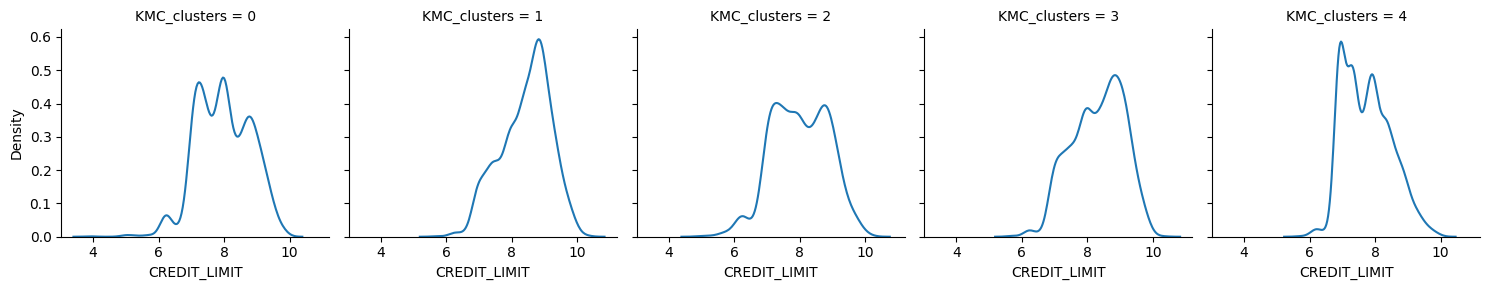

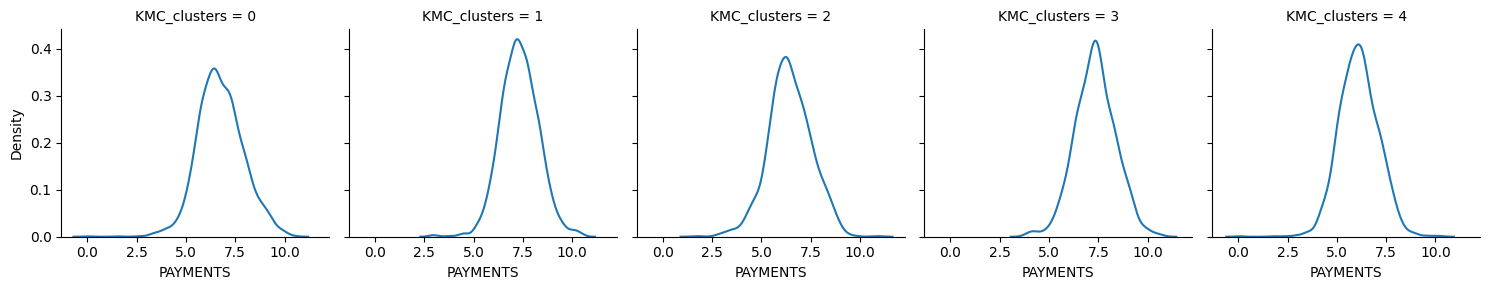

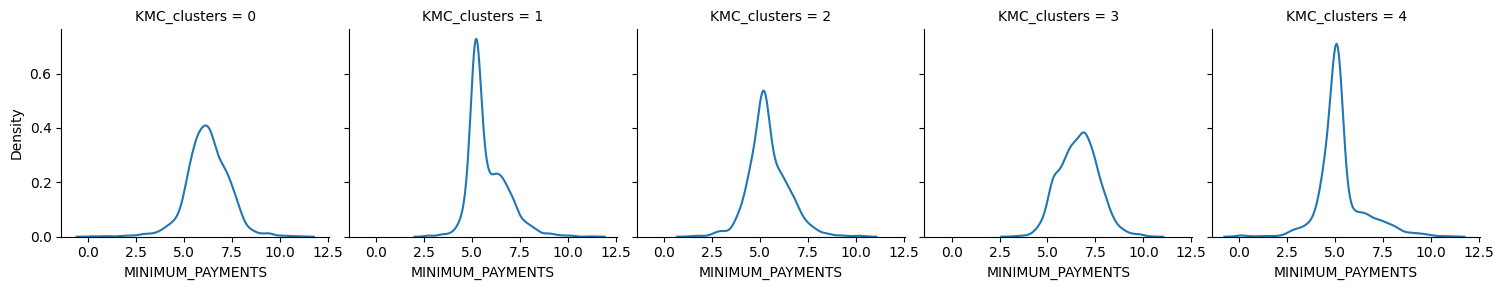

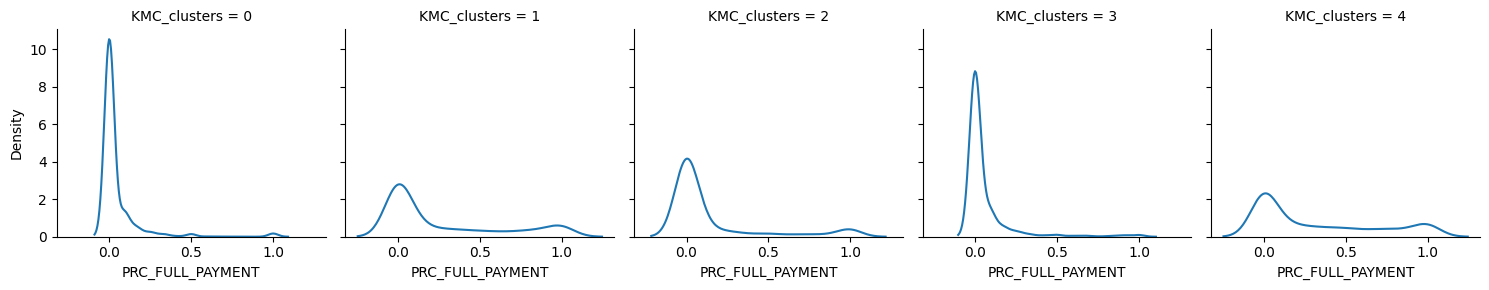

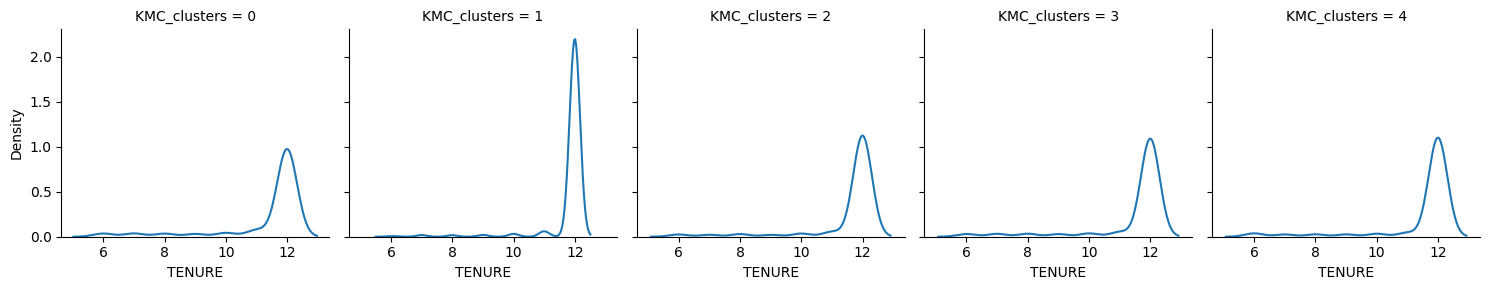

In [50]:
for cluster in data_new.drop(['KMC_clusters'],axis=1):
    grid= sns.FacetGrid(data_new, col='KMC_clusters')
    grid= grid.map(sns.kdeplot, cluster)
plt.show()

<h4><font face="verdona">Seperating different clusters data to understand the data better

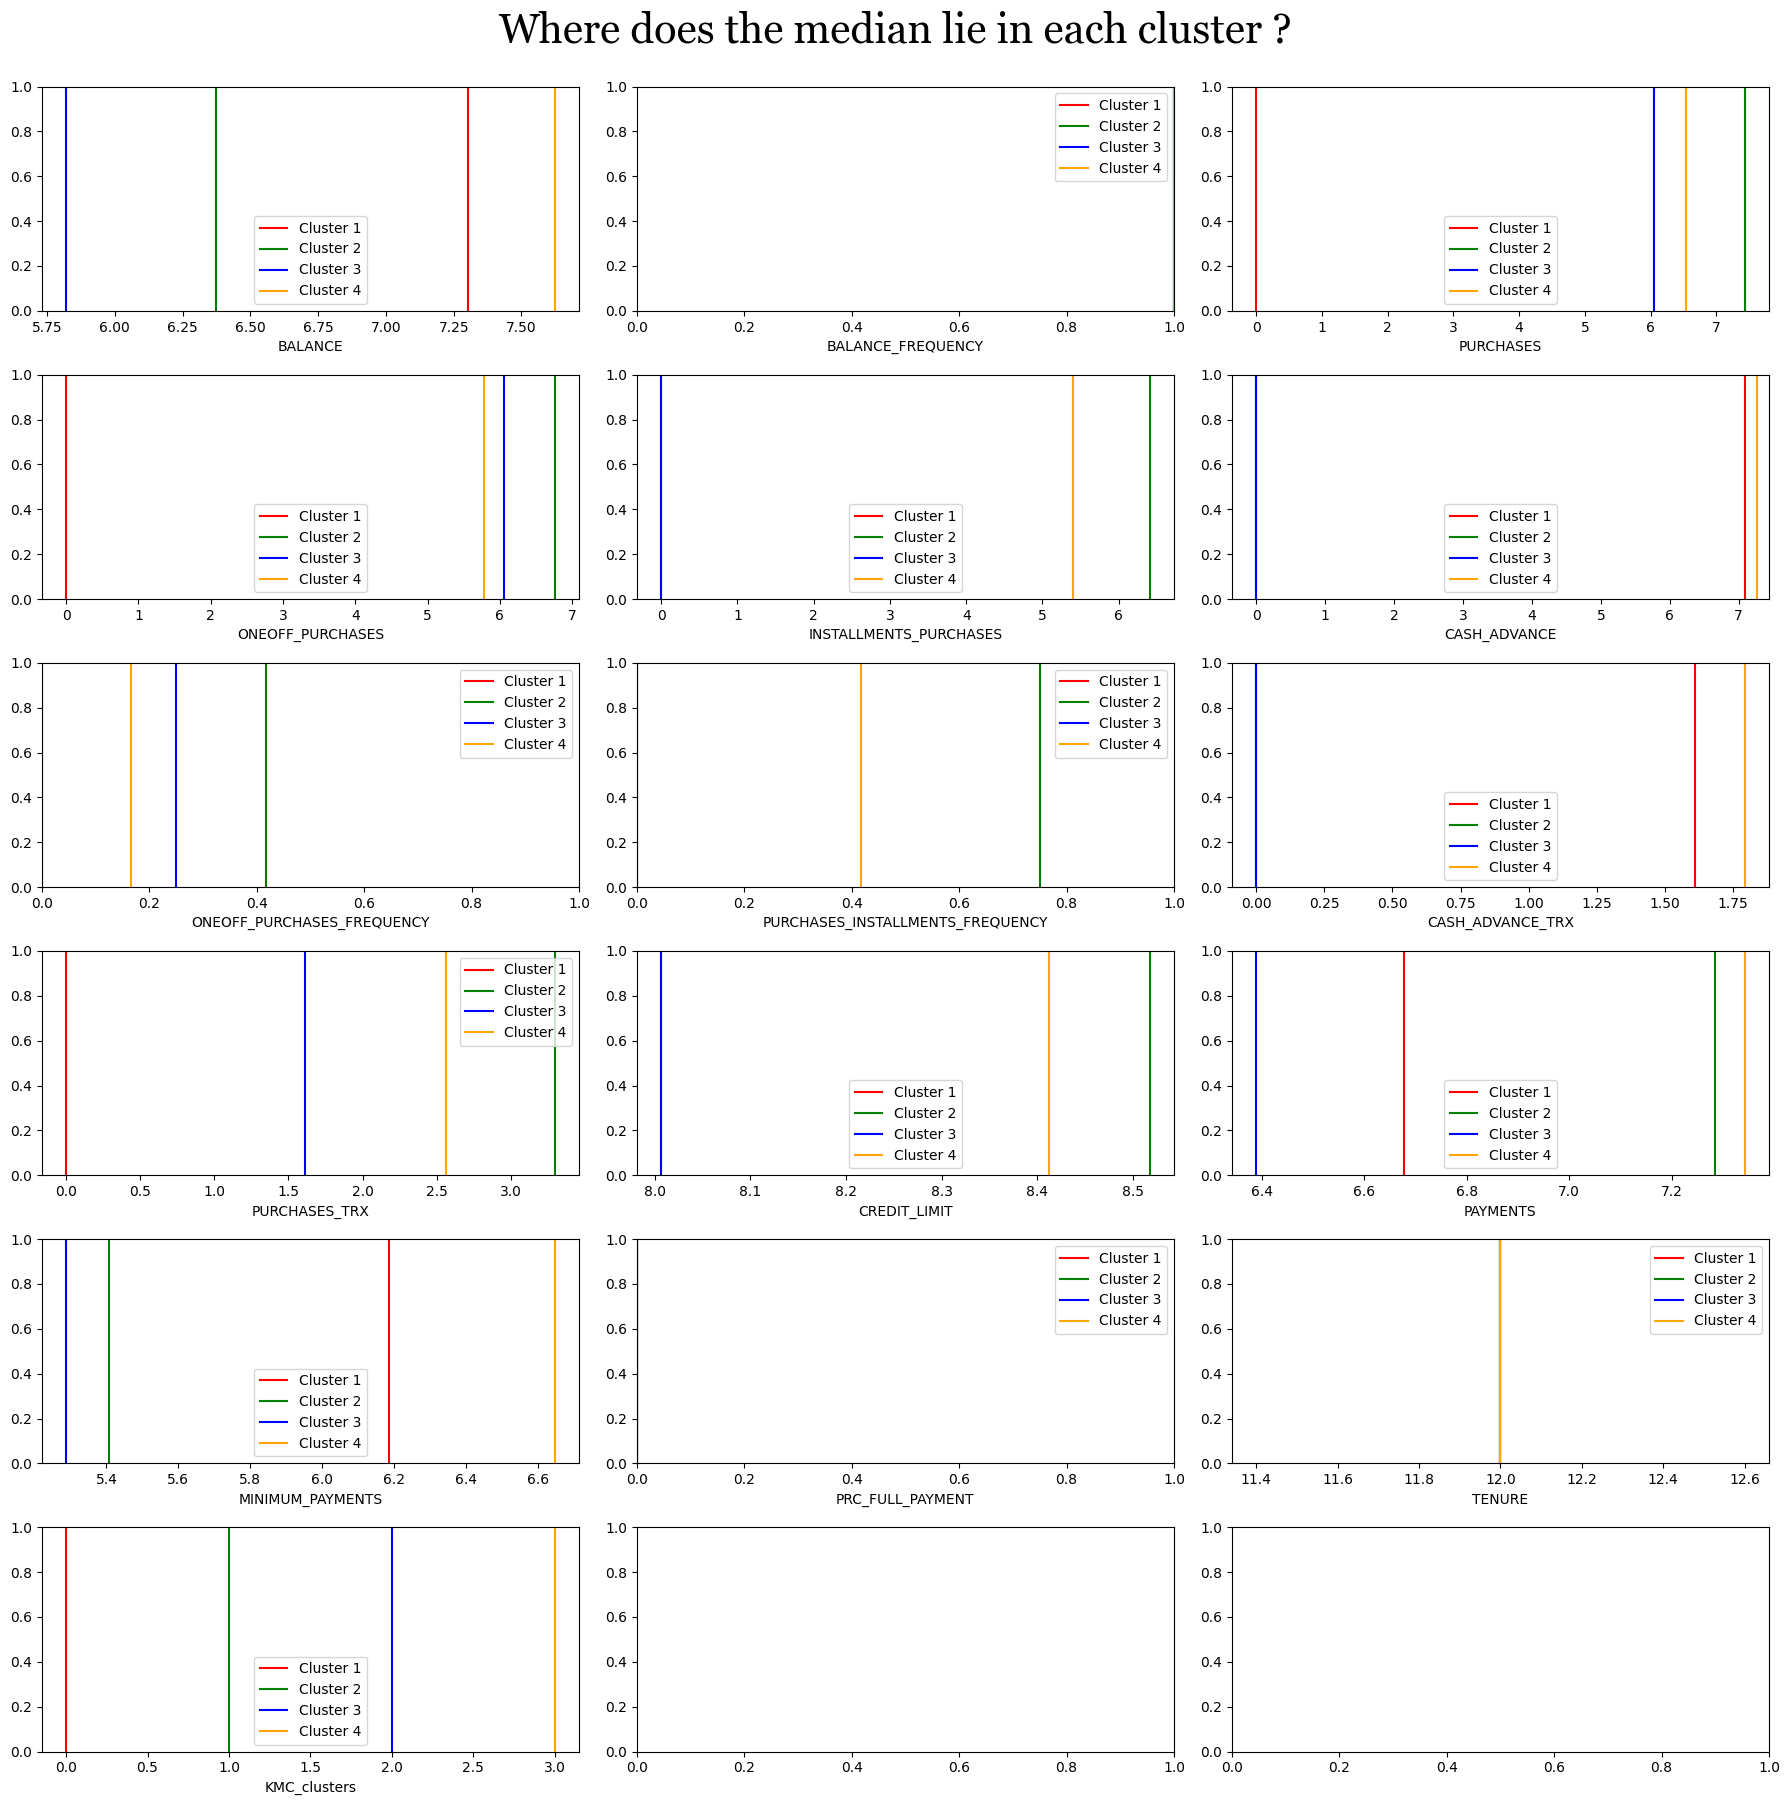

In [51]:
cluster_1_df = data_new[data_new["KMC_clusters"]==0]
cluster_2_df = data_new[data_new["KMC_clusters"]==1]
cluster_3_df = data_new[data_new["KMC_clusters"]==2]
cluster_4_df = data_new[data_new["KMC_clusters"]==3]

num_rows = round((len(data_new.columns) + 1) / 3)
num_cols = 3

fig, ax = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(18, 3 * num_rows))
axes = ax.flatten()

clusters = [cluster_1_df, cluster_2_df, cluster_3_df,cluster_4_df]
colors = ['r','g', 'b', 'orange']
for index, col in enumerate(data_new.columns):
    for cluster_index, cluster_df in enumerate(clusters):
        axes[index].axvline(cluster_df[col].median(), c=colors[cluster_index],
                            label=f'Cluster {cluster_index + 1}', linestyle='-')
    axes[index].set_xlabel(col)
    axes[index].legend()
plt.suptitle('Where does the median lie in each cluster ?', font='georgia', fontsize=30, y=1)
plt.tight_layout()
plt.show()

In [52]:
len(cluster_1_df)

2082

<font face="verdona" color="yellow"><h2>Cluster 0 - </h1><br>
<h2>Cluster 1 - </h2><br>
<h2>Cluster 2 - </h2><br>
<h2>Cluster 3 - </h2><br>
<h2>Cluster 4 - </h2><br> 